# Lezione 4 — metodi, una cella alla volta

**Modulo 4.** Corso di AI applicata, Zucchetti Centro Sistemi.

Ogni cella è indipendente: importa quello che le serve, scarica i dati se mancano, esegue
una sola operazione e ne stampa il risultato. Si esegue in qualsiasi ordine, e se ne può
eseguire una sola.

Le celle marcate `PUNTO DI VARIAZIONE` contengono una costante che cambiamo insieme in aula.
La prima è il detector, ed è anche una scelta di licenza:

| valore | modello | licenza | ms per frame |
|---|---|---|---|
| `yolo11n` | YOLO11 nano, 2,6 M parametri | AGPL-3.0 | ~20 |
| `yolo11s` | YOLO11 small, 9,5 M parametri | AGPL-3.0 | ~45 |
| `yolo11m` | YOLO11 medium, 20,1 M parametri | AGPL-3.0 | ~115 |
| `rtdetr` | RT-DETRv2-R18, 20,2 M parametri | Apache 2.0 | ~190 |

I tempi sono misurati su una CPU a otto thread e servono a confrontare i quattro fra loro:
sulla macchina di chi esegue saranno altri.

Le detection dei quattro modelli sulla clip sono già calcolate e distribuite con i dati, con
il codice che le ha prodotte visibile nella sezione «Un detector pre-addestrato». Le celle
che le usano leggono il file; quelle che misurano un tempo eseguono il modello davvero.

### Dati

**8-Calves**, estratto: 600 frame (30 secondi a 20 frame al secondo, 800×600) di una stalla
ripresa dall'alto, con otto vitelli, e le annotazioni corrispondenti — un bounding box
per vitello per frame, con l'identità.

> Fang, Y. et al. *8-Calves Dataset: Benchmarking Object Detection and Identity
> Classification in Occlusion-Rich Environments.* arXiv:2503.13777.

Fonte: [huggingface.co/datasets/tonyFang04/8-calves](https://huggingface.co/datasets/tonyFang04/8-calves),
licenza [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). L'estratto è ritagliato e
ricompresso rispetto all'originale.

Le annotazioni sono state prodotte dagli autori con un detector affinato, associazione
automatica e correzione manuale. **Anche la verità a terra è in parte prodotta da un
modello**: è la strategia chiamata pseudo-etichette.

### Che cosa serve

`numpy`, `pandas`, `scipy`, `scikit-learn`, `matplotlib`, `opencv-python`, e per eseguire
davvero un detector `ultralytics` oppure `transformers`. Su Colab la prima cella che scarica
i dati impiega una decina di secondi.


## 1 · Ridondanza temporale

Quanto cambia un frame rispetto a quelli che lo seguono, al crescere della distanza temporale.


600 frame, 800x600, venti frame al secondo



differenza media fra due frame, in livelli di grigio su 255:
  distanza    1 frame (  0.1 s)    2.32   #########
  distanza    2 frame (  0.1 s)    3.56   ##############
  distanza    5 frame (  0.2 s)    5.55   ######################
  distanza   10 frame (  0.5 s)    7.33   #############################
  distanza   20 frame (  1.0 s)    8.74   ##################################
  distanza   50 frame (  2.5 s)   10.49   #########################################
  distanza  100 frame (  5.0 s)   12.23   ################################################
  distanza  200 frame ( 10.0 s)   13.69   ######################################################
  distanza  400 frame ( 20.0 s)   14.15   ########################################################

Fra due frame consecutivi la differenza e' 2.32 su 255.
A venti secondi di distanza e' 14.15, cioe' 6 volte la prima.
Oltre una certa distanza la differenza smette di crescere: e' l'ampiezza del
cambiamento della scena, e non dipende piu' da q

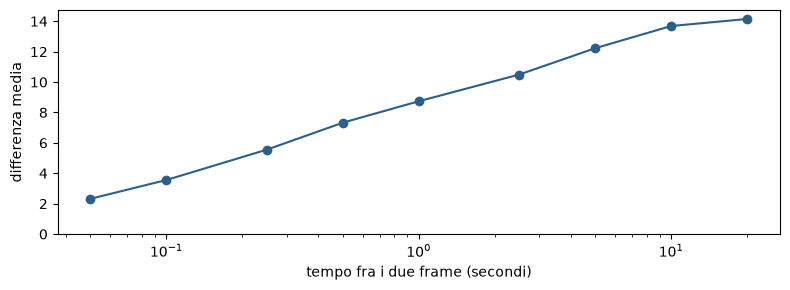

In [1]:
import numpy as np, cv2, matplotlib.pyplot as plt
import pathlib, urllib.request, zipfile, io
D = pathlib.Path("dati-video")
if not (D / "clip.mp4").exists():
    U = "https://github.com/nunziati/zcs-ai-course-2026/releases/download/dati-video/8calves-clip.zip"
    with urllib.request.urlopen(U) as r: zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)
INK, MUTED, BLU, ROS = "#1f2933", "#77828c", "#2c5f8a", "#b8422f"

c = cv2.VideoCapture(str(D / "clip.mp4"))
frame = []
while True:
    ok, im = c.read()
    if not ok: break
    frame.append(cv2.cvtColor(im, cv2.COLOR_BGR2GRAY).astype(np.float32))
c.release()
frame = np.stack(frame)
print(f"{len(frame)} frame, {frame.shape[2]}x{frame.shape[1]}, venti frame al secondo")

passi = [1, 2, 5, 10, 20, 50, 100, 200, 400]
diff = [float(np.abs(frame[:-k] - frame[k:]).mean()) for k in passi]
print("\ndifferenza media fra due frame, in livelli di grigio su 255:")
for k, v in zip(passi, diff):
    print(f"  distanza {k:4d} frame ({k / 20:5.1f} s)   {v:5.2f}   {'#' * int(v * 4)}")
print(f"\nFra due frame consecutivi la differenza e' {diff[0]:.2f} su 255.")
print(f"A venti secondi di distanza e' {diff[-1]:.2f}, cioe' {diff[-1] / diff[0]:.0f} volte la prima.")
print("Oltre una certa distanza la differenza smette di crescere: e' l'ampiezza del")
print("cambiamento della scena, e non dipende piu' da quanto tempo passa.")

fig, ax = plt.subplots(figsize=(8, 3.0))
ax.plot(np.array(passi) / 20, diff, "o-", color=BLU)
ax.set_xscale("log"); ax.set_xlabel("tempo fra i due frame (secondi)")
ax.set_ylabel("differenza media"); ax.set_ylim(bottom=0)
fig.tight_layout(); plt.show()

## 2 · Dallo stream ai campioni

Un frame ogni N: quanti campioni restano, e quanto si sono spostati gli oggetti fra l'uno e l'altro.


In [2]:
import numpy as np, pandas as pd
import pathlib, urllib.request, zipfile, io
D = pathlib.Path("dati-video")
if not (D / "clip.mp4").exists():
    U = "https://github.com/nunziati/zcs-ai-course-2026/releases/download/dati-video/8calves-clip.zip"
    with urllib.request.urlopen(U) as r: zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)
vera = pd.read_csv(D / "clip-verita.csv")
L, A = 800, 600                                   # larghezza e altezza del frame
vera["x1"] = (vera.x - vera.w / 2) * L; vera["y1"] = (vera.y - vera.h / 2) * A
vera["x2"] = (vera.x + vera.w / 2) * L; vera["y2"] = (vera.y + vera.h / 2) * A
B = ["x1", "y1", "x2", "y2"]

print(f"{vera.frame.nunique()} frame annotati, {len(vera)} bounding box, "
      f"{vera.tracklet_id.nunique()} identita'")
lato = float(np.sqrt((vera.w * L) * (vera.h * A)).median())
print(f"lato mediano di un oggetto: {lato:.0f} pixel")

d = vera.assign(cx=vera.x * L, cy=vera.y * A).sort_values(["tracklet_id", "frame"])
print("\n  passo   frame usati   spostamento mediano del centro   in lati di oggetto")
for N in [1, 2, 5, 10, 20, 50, 100]:
    s = d[d.frame % N == 0]
    g = s.groupby("tracklet_id")
    p = float(np.hypot(g.cx.diff(), g.cy.diff()).dropna().median())
    print(f"  {N:5d} {s.frame.nunique():13d}   {p:22.1f} px   {p / lato:14.2f}")

print("\nIl numero di frame da annotare scende come 1/N e lo spostamento fra un frame usato")
print("e il successivo cresce. Il passo diventa inutilizzabile quando lo spostamento")
print("raggiunge il lato dell'oggetto, perche' due bounding box dello stesso vitello")
print("smettono di sovrapporsi, e la sovrapposizione e' l'unica informazione che")
print("l'associazione temporale usa.")
print("In questa scena gli oggetti si muovono poco: anche a cinque secondi di distanza lo")
print("spostamento resta sotto meta' lato. Il passo utile dipende dalla scena, non dal metodo.")

600 frame annotati, 4776 bounding box, 8 identita'
lato mediano di un oggetto: 142 pixel

  passo   frame usati   spostamento mediano del centro   in lati di oggetto
      1           600                      1.3 px             0.01
      2           300                      2.4 px             0.02
      5           120                      5.5 px             0.04
     10            60                      9.4 px             0.07
     20            30                     15.9 px             0.11
     50            12                     39.0 px             0.27
    100             6                     64.8 px             0.45

Il numero di frame da annotare scende come 1/N e lo spostamento fra un frame usato
e il successivo cresce. Il passo diventa inutilizzabile quando lo spostamento
raggiunge il lato dell'oggetto, perche' due bounding box dello stesso vitello
smettono di sovrapporsi, e la sovrapposizione e' l'unica informazione che
l'associazione temporale usa.
In questa scena gli o

## 3 · Split casuale e split temporale

La stessa domanda, imparata su due partizioni diverse degli stessi frame.


In [3]:
import numpy as np, pandas as pd, cv2
from sklearn.neighbors import KNeighborsRegressor
import pathlib, urllib.request, zipfile, io
D = pathlib.Path("dati-video")
if not (D / "clip.mp4").exists():
    U = "https://github.com/nunziati/zcs-ai-course-2026/releases/download/dati-video/8calves-clip.zip"
    with urllib.request.urlopen(U) as r: zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)
vera = pd.read_csv(D / "clip-verita.csv")
L, A = 800, 600                                   # larghezza e altezza del frame
vera["x1"] = (vera.x - vera.w / 2) * L; vera["y1"] = (vera.y - vera.h / 2) * A
vera["x2"] = (vera.x + vera.w / 2) * L; vera["y2"] = (vera.y + vera.h / 2) * A
B = ["x1", "y1", "x2", "y2"]

c = cv2.VideoCapture(str(D / "clip.mp4"))
X = []
while True:
    ok, im = c.read()
    if not ok: break
    g = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    X.append(cv2.resize(g, (32, 24)).ravel().astype(np.float32) / 255)
c.release()
X = np.stack(X)

# la domanda: dov'e' il vitello 1, in orizzontale, in questo frame
uno = vera[vera.tracklet_id == 1].set_index("frame").sort_index()
y = (uno.x.reindex(range(len(X))).interpolate().bfill().values * L)
i = np.arange(len(X))
TAGLIO = int(len(X) * 0.7)

def errore(tr, te):
    m = KNeighborsRegressor(3).fit(X[tr], y[tr])
    return float(np.abs(m.predict(X[te]) - y[te]).mean())

rng = np.random.default_rng(0)
casuale = rng.permutation(i)
e_casuale = errore(casuale[:TAGLIO], casuale[TAGLIO:])
e_tempo = errore(i[:TAGLIO], i[TAGLIO:])
e_media = float(np.abs(y[TAGLIO:] - y[:TAGLIO].mean()).mean())

print(f"split casuale dei frame    errore medio {e_casuale:6.1f} pixel")
print(f"split temporale            errore medio {e_tempo:6.1f} pixel")
print(f"nessun modello, la media   errore medio {e_media:6.1f} pixel")

vicino = np.abs(np.subtract.outer(casuale[TAGLIO:], casuale[:TAGLIO])).min(1)
print(f"\nNello split casuale il frame di addestramento piu' vicino nel tempo a un frame di")
print(f"test dista in mediana {np.median(vicino):.0f} frame, cioe' {np.median(vicino) / 20:.2f} secondi.")
print("Il modello non ha imparato dove sta il vitello: ha ritrovato un frame quasi")
print("identico e ne ha copiato la risposta. Lo split temporale rende impossibile quella via.")

split casuale dei frame    errore medio    0.5 pixel
split temporale            errore medio    7.5 pixel
nessun modello, la media   errore medio   20.4 pixel

Nello split casuale il frame di addestramento piu' vicino nel tempo a un frame di
test dista in mediana 1 frame, cioe' 0.05 secondi.
Il modello non ha imparato dove sta il vitello: ha ritrovato un frame quasi
identico e ne ha copiato la risposta. Lo split temporale rende impossibile quella via.


## 4 · Un detector pre-addestrato, su un dominio diverso

Il modello e' addestrato su COCO. La scena e' una stalla ripresa dall'alto.


In [4]:
import numpy as np, cv2, time, collections
import pathlib, urllib.request, zipfile, io
D = pathlib.Path("dati-video")
if not (D / "clip.mp4").exists():
    U = "https://github.com/nunziati/zcs-ai-course-2026/releases/download/dati-video/8calves-clip.zip"
    with urllib.request.urlopen(U) as r: zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)
# PUNTO DI VARIAZIONE
# yolo11n, yolo11s, yolo11m (AGPL-3.0)   oppure   rtdetr (Apache 2.0)
DETECTOR = "yolo11m"
ANIMALI = {"cow", "dog", "bird", "sheep", "bear", "cat", "horse", "elephant", "zebra", "giraffe"}
def serve(modulo, pacchetto=None):
    """Su Colab ultralytics non c'e'. Si installa una volta sola, al primo uso."""
    import importlib, subprocess, sys
    try: return importlib.import_module(modulo)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pacchetto or modulo], check=True)
        return importlib.import_module(modulo)

if DETECTOR.startswith("yolo"):
    serve("ultralytics")
    from ultralytics import YOLO
    mod = YOLO(DETECTOR + ".pt")
    def rileva(im, lato=640, soglia=0.10):
        r = mod.predict(im, verbose=False, imgsz=lato, conf=soglia)[0]
        return (r.boxes.xyxy.numpy(), r.boxes.conf.numpy(),
                [r.names[int(k)] for k in r.boxes.cls])
else:
    import torch
    from PIL import Image
    serve("transformers", "transformers>=4.47")
    from transformers import RTDetrV2ForObjectDetection, RTDetrImageProcessor
    CK = "PekingU/rtdetr_v2_r18vd"
    proc = RTDetrImageProcessor.from_pretrained(CK)
    mod = RTDetrV2ForObjectDetection.from_pretrained(CK).eval()
    def rileva(im, lato=640, soglia=0.10):
        img = Image.fromarray(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        misura = {"height": lato, "width": lato}
        with torch.no_grad():
            out = mod(**proc(images=img, return_tensors="pt", size=misura))
        r = proc.post_process_object_detection(
            out, target_sizes=torch.tensor([[600, 800]]), threshold=soglia)[0]
        return (r["boxes"].numpy(), r["scores"].numpy(),
                [mod.config.id2label[k.item()] for k in r["labels"]])

c = cv2.VideoCapture(str(D / "clip.mp4"))
frame = [c.read()[1] for _ in range(6)]
c.release()

npar = sum(p.numel() for p in (mod.model if DETECTOR.startswith("yolo") else mod).parameters()) / 1e6
rileva(frame[0])                                   # riscaldamento
t = []
for im in frame:
    t0 = time.perf_counter(); rileva(im); t.append(time.perf_counter() - t0)
print(f"{DETECTOR}: {npar:.1f} milioni di parametri, "
      f"{np.median(t) * 1000:.0f} ms per frame su questa macchina")

# le classi si contano sulle detection gia' calcolate, su tutti i 600 frame
import pandas as pd
det = pd.read_csv(D / ("det-" + DETECTOR + ".csv"))
classi = collections.Counter(det[det.conf >= 0.25].classe)
print(f"\nclassi assegnate sopra 0,25 su tutta la clip:")
for k, v in classi.most_common(8):
    print(f"  {k:10s} {v:5d}   {'#' * int(40 * v / max(classi.values()))}")
vivi = sum(v for k, v in classi.items() if k in ANIMALI)
print(f"\nriconducibili a un animale: {vivi} su {sum(classi.values())}")
print("Gli oggetti sono otto vitelli. COCO non ha la classe vitello e non contiene animali")
print("ripresi dal soffitto: il modello li trova, e la classe che assegna cambia da un frame")
print("all'altro. Da qui in avanti la classe e' ignorata e vale qualunque animale.")

yolo11m: 20.1 milioni di parametri, 114 ms per frame su questa macchina

classi assegnate sopra 0,25 su tutta la clip:
  cow         1956   ########################################
  bird        1709   ##################################
  sheep         59   #
  dog           19   
  person         5   
  horse          1   

riconducibili a un animale: 3744 su 3749
Gli oggetti sono otto vitelli. COCO non ha la classe vitello e non contiene animali
ripresi dal soffitto: il modello li trova, e la classe che assegna cambia da un frame
all'altro. Da qui in avanti la classe e' ignorata e vale qualunque animale.


## 5 · Bounding box duplicati e soppressione

Quanti bounding box escono per otto oggetti, e che cosa toglie la soppressione.


In [5]:
import numpy as np, pandas as pd
import pathlib, urllib.request, zipfile, io
D = pathlib.Path("dati-video")
if not (D / "clip.mp4").exists():
    U = "https://github.com/nunziati/zcs-ai-course-2026/releases/download/dati-video/8calves-clip.zip"
    with urllib.request.urlopen(U) as r: zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)
# PUNTO DI VARIAZIONE
# yolo11n, yolo11s, yolo11m (AGPL-3.0)   oppure   rtdetr (Apache 2.0)
DETECTOR = "yolo11m"
vera = pd.read_csv(D / "clip-verita.csv")
L, A = 800, 600                                   # larghezza e altezza del frame
vera["x1"] = (vera.x - vera.w / 2) * L; vera["y1"] = (vera.y - vera.h / 2) * A
vera["x2"] = (vera.x + vera.w / 2) * L; vera["y2"] = (vera.y + vera.h / 2) * A
B = ["x1", "y1", "x2", "y2"]
ANIMALI = {"cow", "dog", "bird", "sheep", "bear", "cat", "horse", "elephant", "zebra", "giraffe"}
def iou(a, b):
    """Matrice di intersezione su unione fra due insiemi di bounding box (x1, y1, x2, y2)."""
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    dentro = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    aa = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]); bb = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return dentro / (aa[:, None] + bb[None, :] - dentro + 1e-9)
def nms(b, s, soglia=0.6):
    """Soppressione dei duplicati: tiene il punteggio piu' alto, scarta chi vi si sovrappone."""
    ordine = np.argsort(-s); tenuti = []
    while len(ordine):
        k = ordine[0]; tenuti.append(k)
        if len(ordine) == 1: break
        ordine = ordine[1:][iou(b[k:k + 1], b[ordine[1:]])[0] < soglia]
    return tenuti

# le uscite del modello prima della soppressione dei duplicati; per un detector che
# non ha quel passo, l'uscita normale e' gia' quella grezza
grezze = D / ("det-" + DETECTOR + "-grezze.csv")
if not grezze.exists(): grezze = D / ("det-" + DETECTOR + ".csv")
det = pd.read_csv(grezze)
det = det[det.classe.isin(ANIMALI) & (det.conf >= 0.25)]
nf = vera.frame.nunique()

print(f"detector: {DETECTOR}, soglia di confidenza 0,25, otto oggetti veri per frame")
print(f"\n{'NMS':>8}{'bounding box/frame':>21}{'richiamo':>11}{'precisione':>13}")
for soglia in [None, 0.90, 0.70, 0.50, 0.30]:
    tp = fp = ng = nb = 0
    for f, g in det.groupby("frame"):
        b, s = g[B].values, g.conf.values
        if soglia is not None:
            k = nms(b, s, soglia); b = b[k]
        nb += len(b)
        v = vera[vera.frame == f][B].values; ng += len(v)
        if len(b):
            m = iou(v, b); tp += int((m.max(1) >= 0.5).sum()); fp += int((m.max(0) < 0.5).sum())
    et = "nessuna" if soglia is None else f"{soglia:.2f}"
    print(f"{et:>8}{nb / nf:21.1f}{tp / ng:11.2f}{tp / max(tp + fp, 1):13.2f}")
print("\nSenza soppressione il modello emette molti bounding box per ogni oggetto. La")
print("soppressione ne toglie la maggior parte e non tocca il richiamo: sono duplicati,")
print("non oggetti. Sotto una certa soglia comincia invece a togliere oggetti veri vicini")
print("fra loro, e il richiamo scende.")

detector: yolo11m, soglia di confidenza 0,25, otto oggetti veri per frame

     NMS   bounding box/frame   richiamo   precisione


 nessuna                 25.0       0.60         0.48


    0.90                  6.4       0.59         0.79


    0.70                  5.9       0.59         0.80


    0.50                  5.8       0.59         0.81


    0.30                  5.7       0.58         0.81

Senza soppressione il modello emette molti bounding box per ogni oggetto. La
soppressione ne toglie la maggior parte e non tocca il richiamo: sono duplicati,
non oggetti. Sotto una certa soglia comincia invece a togliere oggetti veri vicini
fra loro, e il richiamo scende.


## 6 · Risoluzione, accuratezza e tempo

Lo stesso modello sugli stessi frame, a tre risoluzioni di ingresso.


In [6]:
import numpy as np, pandas as pd, cv2, time
import pathlib, urllib.request, zipfile, io
D = pathlib.Path("dati-video")
if not (D / "clip.mp4").exists():
    U = "https://github.com/nunziati/zcs-ai-course-2026/releases/download/dati-video/8calves-clip.zip"
    with urllib.request.urlopen(U) as r: zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)
# PUNTO DI VARIAZIONE
# yolo11n, yolo11s, yolo11m (AGPL-3.0)   oppure   rtdetr (Apache 2.0)
DETECTOR = "yolo11m"
vera = pd.read_csv(D / "clip-verita.csv")
L, A = 800, 600                                   # larghezza e altezza del frame
vera["x1"] = (vera.x - vera.w / 2) * L; vera["y1"] = (vera.y - vera.h / 2) * A
vera["x2"] = (vera.x + vera.w / 2) * L; vera["y2"] = (vera.y + vera.h / 2) * A
B = ["x1", "y1", "x2", "y2"]
ANIMALI = {"cow", "dog", "bird", "sheep", "bear", "cat", "horse", "elephant", "zebra", "giraffe"}
def iou(a, b):
    """Matrice di intersezione su unione fra due insiemi di bounding box (x1, y1, x2, y2)."""
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    dentro = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    aa = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]); bb = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return dentro / (aa[:, None] + bb[None, :] - dentro + 1e-9)
def serve(modulo, pacchetto=None):
    """Su Colab ultralytics non c'e'. Si installa una volta sola, al primo uso."""
    import importlib, subprocess, sys
    try: return importlib.import_module(modulo)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pacchetto or modulo], check=True)
        return importlib.import_module(modulo)

if DETECTOR.startswith("yolo"):
    serve("ultralytics")
    from ultralytics import YOLO
    mod = YOLO(DETECTOR + ".pt")
    def rileva(im, lato=640, soglia=0.10):
        r = mod.predict(im, verbose=False, imgsz=lato, conf=soglia)[0]
        return (r.boxes.xyxy.numpy(), r.boxes.conf.numpy(),
                [r.names[int(k)] for k in r.boxes.cls])
else:
    import torch
    from PIL import Image
    serve("transformers", "transformers>=4.47")
    from transformers import RTDetrV2ForObjectDetection, RTDetrImageProcessor
    CK = "PekingU/rtdetr_v2_r18vd"
    proc = RTDetrImageProcessor.from_pretrained(CK)
    mod = RTDetrV2ForObjectDetection.from_pretrained(CK).eval()
    def rileva(im, lato=640, soglia=0.10):
        img = Image.fromarray(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        misura = {"height": lato, "width": lato}
        with torch.no_grad():
            out = mod(**proc(images=img, return_tensors="pt", size=misura))
        r = proc.post_process_object_detection(
            out, target_sizes=torch.tensor([[600, 800]]), threshold=soglia)[0]
        return (r["boxes"].numpy(), r["scores"].numpy(),
                [mod.config.id2label[k.item()] for k in r["labels"]])

FRAME = list(range(0, 200, 10))                    # venti frame
c = cv2.VideoCapture(str(D / "clip.mp4")); im = []
for i in range(max(FRAME) + 1):
    ok, f = c.read()
    if i in FRAME: im.append(f)
c.release()

rileva(im[0], 320)
print(f"detector: {DETECTOR}, venti frame, soglia 0,25")
print(f"\n{'ingresso':>10}{'ms/frame':>11}{'richiamo':>11}{'precisione':>13}")
for lato in (640, 480, 320):
    tp = fp = ng = 0; t = []
    for f, x in zip(FRAME, im):
        t0 = time.perf_counter(); b, s, n = rileva(x, lato, 0.25); t.append(time.perf_counter() - t0)
        k = [j for j, q in enumerate(n) if q in ANIMALI]; b = b[k]
        v = vera[vera.frame == f][B].values; ng += len(v)
        if len(b):
            m = iou(v, b); tp += int((m.max(1) >= 0.5).sum()); fp += int((m.max(0) < 0.5).sum())
    print(f"{str(lato) + ' px':>10}{np.median(t) * 1000:11.0f}{tp / ng:11.2f}{tp / max(tp + fp, 1):13.2f}")
print("\nIl frame e' 800x600 e viene ricondotto al lato di ingresso: la riduzione si applica")
print("anche agli oggetti. Qui i vitelli occupano quasi un sesto del lato del frame, quindi")
print("restano grandi anche a 320 e ridurre l'ingresso costa poco. Su una scena con oggetti")
print("piccoli lo stesso taglio li porta sotto la soglia di rilevabilita' e il richiamo")
print("crolla. La forma della curva dipende dalla taglia degli oggetti, non dal modello.")

detector: yolo11m, venti frame, soglia 0,25

  ingresso   ms/frame   richiamo   precisione


    640 px        115       0.45         0.68


    480 px         66       0.54         0.75


    320 px         35       0.56         0.69

Il frame e' 800x600 e viene ricondotto al lato di ingresso: la riduzione si applica
anche agli oggetti. Qui i vitelli occupano quasi un sesto del lato del frame, quindi
restano grandi anche a 320 e ridurre l'ingresso costa poco. Su una scena con oggetti
piccoli lo stesso taglio li porta sotto la soglia di rilevabilita' e il richiamo
crolla. La forma della curva dipende dalla taglia degli oggetti, non dal modello.


## 7 · Inferenza a tile

Lo stesso ingresso da 320 pixel, speso sul frame intero oppure su quattro porzioni.


In [7]:
import numpy as np, pandas as pd, cv2, time
import pathlib, urllib.request, zipfile, io
D = pathlib.Path("dati-video")
if not (D / "clip.mp4").exists():
    U = "https://github.com/nunziati/zcs-ai-course-2026/releases/download/dati-video/8calves-clip.zip"
    with urllib.request.urlopen(U) as r: zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)
# PUNTO DI VARIAZIONE
# yolo11n, yolo11s, yolo11m (AGPL-3.0)   oppure   rtdetr (Apache 2.0)
DETECTOR = "yolo11m"
vera = pd.read_csv(D / "clip-verita.csv")
L, A = 800, 600                                   # larghezza e altezza del frame
vera["x1"] = (vera.x - vera.w / 2) * L; vera["y1"] = (vera.y - vera.h / 2) * A
vera["x2"] = (vera.x + vera.w / 2) * L; vera["y2"] = (vera.y + vera.h / 2) * A
B = ["x1", "y1", "x2", "y2"]
ANIMALI = {"cow", "dog", "bird", "sheep", "bear", "cat", "horse", "elephant", "zebra", "giraffe"}
def iou(a, b):
    """Matrice di intersezione su unione fra due insiemi di bounding box (x1, y1, x2, y2)."""
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    dentro = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    aa = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]); bb = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return dentro / (aa[:, None] + bb[None, :] - dentro + 1e-9)
def nms(b, s, soglia=0.6):
    """Soppressione dei duplicati: tiene il punteggio piu' alto, scarta chi vi si sovrappone."""
    ordine = np.argsort(-s); tenuti = []
    while len(ordine):
        k = ordine[0]; tenuti.append(k)
        if len(ordine) == 1: break
        ordine = ordine[1:][iou(b[k:k + 1], b[ordine[1:]])[0] < soglia]
    return tenuti
def serve(modulo, pacchetto=None):
    """Su Colab ultralytics non c'e'. Si installa una volta sola, al primo uso."""
    import importlib, subprocess, sys
    try: return importlib.import_module(modulo)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pacchetto or modulo], check=True)
        return importlib.import_module(modulo)

if DETECTOR.startswith("yolo"):
    serve("ultralytics")
    from ultralytics import YOLO
    mod = YOLO(DETECTOR + ".pt")
    def rileva(im, lato=640, soglia=0.10):
        r = mod.predict(im, verbose=False, imgsz=lato, conf=soglia)[0]
        return (r.boxes.xyxy.numpy(), r.boxes.conf.numpy(),
                [r.names[int(k)] for k in r.boxes.cls])
else:
    import torch
    from PIL import Image
    serve("transformers", "transformers>=4.47")
    from transformers import RTDetrV2ForObjectDetection, RTDetrImageProcessor
    CK = "PekingU/rtdetr_v2_r18vd"
    proc = RTDetrImageProcessor.from_pretrained(CK)
    mod = RTDetrV2ForObjectDetection.from_pretrained(CK).eval()
    def rileva(im, lato=640, soglia=0.10):
        img = Image.fromarray(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        misura = {"height": lato, "width": lato}
        with torch.no_grad():
            out = mod(**proc(images=img, return_tensors="pt", size=misura))
        r = proc.post_process_object_detection(
            out, target_sizes=torch.tensor([[600, 800]]), threshold=soglia)[0]
        return (r["boxes"].numpy(), r["scores"].numpy(),
                [mod.config.id2label[k.item()] for k in r["labels"]])

FRAME = list(range(0, 200, 20))                    # dieci frame
c = cv2.VideoCapture(str(D / "clip.mp4")); im = []
for i in range(max(FRAME) + 1):
    ok, f = c.read()
    if i in FRAME: im.append(f)
c.release()

def animali(b, s, n):
    k = [j for j, q in enumerate(n) if q in ANIMALI]
    return b[k], s[k]

def a_tile(x, lato=320, righe=2, colonne=2, sovr=0.2):
    """Ritaglia il frame in tile sovrapposti, rileva su ciascuno, ricompone."""
    H, W = x.shape[:2]
    ph, pw = int(H / righe * (1 + sovr)), int(W / colonne * (1 + sovr))
    tutte_b, tutte_s = [], []
    for r in range(righe):
        for q in range(colonne):
            y0 = min(int(r * H / righe), H - ph); x0 = min(int(q * W / colonne), W - pw)
            b, s, n = rileva(x[y0:y0 + ph, x0:x0 + pw], lato, 0.25)
            b, s = animali(b, s, n)
            if len(b):
                b = b + np.array([x0, y0, x0, y0]); tutte_b.append(b); tutte_s.append(s)
    if not tutte_b: return np.zeros((0, 4)), righe * colonne
    b = np.vstack(tutte_b); s = np.concatenate(tutte_s)
    return b[nms(b, s, 0.6)], righe * colonne

rileva(im[0], 320)
lato_oggetto = float(np.sqrt((vera.w * L) * (vera.h * A)).median())
print(f"detector: {DETECTOR}, dieci frame")
print(f"lato mediano di un oggetto: {lato_oggetto:.0f} px su un frame {L}x{A}")
intestazione = ["ingresso", "oggetto li dentro", "modo", "passaggi", "ms/frame", "richiamo"]
print("\n" + f"{intestazione[0]:>9}{intestazione[1]:>19}{intestazione[2]:>15}"
      f"{intestazione[3]:>10}{intestazione[4]:>10}{intestazione[5]:>10}")
for lato in (160, 224, 320):
    for modo in ("frame intero", "quattro tile"):
        tp = ng = 0; t = []; passaggi = 1
        for f, x in zip(FRAME, im):
            t0 = time.perf_counter()
            if modo == "frame intero":
                b, s, n = rileva(x, lato, 0.25); b, s = animali(b, s, n)
            else:
                b, passaggi = a_tile(x, lato=lato)
            t.append(time.perf_counter() - t0)
            v = vera[vera.frame == f][B].values; ng += len(v)
            if len(b): tp += int((iou(v, b).max(1) >= 0.5).sum())
        # quanti pixel restano all oggetto una volta ricondotto all ingresso del modello
        sorgente = max(L, A) if modo == "frame intero" else max(L / 2 * 1.2, A / 2 * 1.2)
        print(f"{lato:7d}px{lato_oggetto * lato / sorgente:16.0f} px{modo:>15}"
              f"{passaggi:10d}{np.median(t) * 1000:10.0f}{tp / ng:10.2f}")
print("\nI tile si sovrappongono perche un oggetto a cavallo di due porzioni sia contenuto")
print("per intero in almeno una, e il costo si moltiplica per il numero di tile.")
print("Il guadagno non e' garantito: compare solo dove l'oggetto, ricondotto all'ingresso")
print("del modello, scende sotto le poche decine di pixel. Sopra quella soglia i quattro")
print("passaggi costano e non rendono, perche' l'oggetto era gia' abbastanza grande.")

detector: yolo11m, dieci frame
lato mediano di un oggetto: 142 px su un frame 800x600

 ingresso  oggetto li dentro           modo  passaggi  ms/frame  richiamo
    160px              28 px   frame intero         1        15      0.30


    160px              47 px   quattro tile         4        59      0.42


    224px              40 px   frame intero         1        23      0.42


    224px              66 px   quattro tile         4        91      0.48


    320px              57 px   frame intero         1        35      0.56


    320px              95 px   quattro tile         4       139      0.43

I tile si sovrappongono perche un oggetto a cavallo di due porzioni sia contenuto
per intero in almeno una, e il costo si moltiplica per il numero di tile.
Il guadagno non e' garantito: compare solo dove l'oggetto, ricondotto all'ingresso
del modello, scende sotto le poche decine di pixel. Sopra quella soglia i quattro
passaggi costano e non rendono, perche' l'oggetto era gia' abbastanza grande.


## 8 · Intersezione su unione, e la sua soglia

Due modelli sugli stessi frame, al variare della soglia di sovrapposizione.


  soglia   yolo11n   yolo11m


    0.30      0.44      0.73
    0.35      0.43      0.70
    0.40      0.41      0.67
    0.45      0.38      0.63
    0.50      0.36      0.59
    0.55      0.32      0.54
    0.60      0.29      0.49
    0.65      0.23      0.41
    0.70      0.18      0.35
    0.75      0.14      0.27
    0.80      0.10      0.19
    0.85      0.05      0.10
    0.90      0.01      0.03
    0.95      0.00      0.00

sovrapposizione mediana dei bounding box abbinati: yolo11n 0.54, yolo11m 0.61
i due modelli si invertono da qualche parte: no

Qui uno dei due domina l'altro a ogni soglia, quindi la scelta fra i due non
dipende dalla soglia. Il numero riportato si': fra 0,30 e 0,90 la frazione di
oggetti trovati passa da quasi tre quarti a quasi zero, sugli stessi identici
bounding box. Un valore riportato senza la soglia accanto non e' interpretabile.


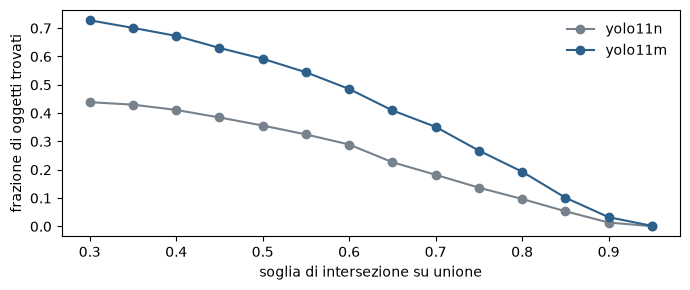

In [8]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pathlib, urllib.request, zipfile, io
D = pathlib.Path("dati-video")
if not (D / "clip.mp4").exists():
    U = "https://github.com/nunziati/zcs-ai-course-2026/releases/download/dati-video/8calves-clip.zip"
    with urllib.request.urlopen(U) as r: zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)
vera = pd.read_csv(D / "clip-verita.csv")
L, A = 800, 600                                   # larghezza e altezza del frame
vera["x1"] = (vera.x - vera.w / 2) * L; vera["y1"] = (vera.y - vera.h / 2) * A
vera["x2"] = (vera.x + vera.w / 2) * L; vera["y2"] = (vera.y + vera.h / 2) * A
B = ["x1", "y1", "x2", "y2"]
ANIMALI = {"cow", "dog", "bird", "sheep", "bear", "cat", "horse", "elephant", "zebra", "giraffe"}
def iou(a, b):
    """Matrice di intersezione su unione fra due insiemi di bounding box (x1, y1, x2, y2)."""
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    dentro = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    aa = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]); bb = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return dentro / (aa[:, None] + bb[None, :] - dentro + 1e-9)
INK, MUTED, BLU, ROS = "#1f2933", "#77828c", "#2c5f8a", "#b8422f"

def richiamo(nome, soglie):
    det = pd.read_csv(D / ("det-" + nome + ".csv"))
    det = det[det.classe.isin(ANIMALI) & (det.conf >= 0.25)]
    massimi = []
    for f, v in vera.groupby("frame"):
        b = det[det.frame == f][B].values
        g = v[B].values
        massimi.append(iou(g, b).max(1) if len(b) else np.zeros(len(g)))
    massimi = np.concatenate(massimi)
    return massimi, [float((massimi >= s).mean()) for s in soglie]

soglie = np.arange(0.30, 0.96, 0.05)
print(f"{'soglia':>8}{'yolo11n':>10}{'yolo11m':>10}")
m_n, r_n = richiamo("yolo11n", soglie)
m_m, r_m = richiamo("yolo11m", soglie)
for s, a, b in zip(soglie, r_n, r_m):
    print(f"{s:8.2f}{a:10.2f}{b:10.2f}")
print(f"\nsovrapposizione mediana dei bounding box abbinati: "
      f"yolo11n {np.median(m_n[m_n > 0]):.2f}, yolo11m {np.median(m_m[m_m > 0]):.2f}")
inverte = any((a > b) != (r_n[0] > r_m[0]) for a, b in zip(r_n, r_m))
print("i due modelli si invertono da qualche parte:", "si" if inverte else "no")
print("\nQui uno dei due domina l'altro a ogni soglia, quindi la scelta fra i due non")
print("dipende dalla soglia. Il numero riportato si': fra 0,30 e 0,90 la frazione di")
print("oggetti trovati passa da quasi tre quarti a quasi zero, sugli stessi identici")
print("bounding box. Un valore riportato senza la soglia accanto non e' interpretabile.")

fig, ax = plt.subplots(figsize=(7, 3.0))
ax.plot(soglie, r_n, "o-", color=MUTED, label="yolo11n")
ax.plot(soglie, r_m, "o-", color=BLU, label="yolo11m")
ax.set_xlabel("soglia di intersezione su unione"); ax.set_ylabel("frazione di oggetti trovati")
ax.legend(frameon=False); fig.tight_layout(); plt.show()

## 9 · Curva precisione-richiamo e average precision

Le predizioni ordinate per punteggio, e l'area sotto la curva che ne risulta.


detector: yolo11m, soglia di sovrapposizione 0,50
predizioni: 6067   oggetti veri: 4776
average precision: 0.611

   punto della curva   richiamo   precisione
                           0.07         0.89
                           0.22         0.88
                           0.37         0.85
                           0.52         0.80
                           0.67         0.67

La curva riassume tutte le soglie di confidenza in una volta. L'average precision
e' la sua area, e non dice quale soglia usare in esercizio.


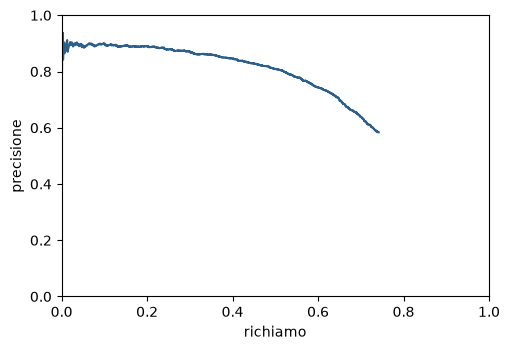

In [9]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pathlib, urllib.request, zipfile, io
D = pathlib.Path("dati-video")
if not (D / "clip.mp4").exists():
    U = "https://github.com/nunziati/zcs-ai-course-2026/releases/download/dati-video/8calves-clip.zip"
    with urllib.request.urlopen(U) as r: zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)
# PUNTO DI VARIAZIONE
# yolo11n, yolo11s, yolo11m (AGPL-3.0)   oppure   rtdetr (Apache 2.0)
DETECTOR = "yolo11m"
vera = pd.read_csv(D / "clip-verita.csv")
L, A = 800, 600                                   # larghezza e altezza del frame
vera["x1"] = (vera.x - vera.w / 2) * L; vera["y1"] = (vera.y - vera.h / 2) * A
vera["x2"] = (vera.x + vera.w / 2) * L; vera["y2"] = (vera.y + vera.h / 2) * A
B = ["x1", "y1", "x2", "y2"]
ANIMALI = {"cow", "dog", "bird", "sheep", "bear", "cat", "horse", "elephant", "zebra", "giraffe"}
def iou(a, b):
    """Matrice di intersezione su unione fra due insiemi di bounding box (x1, y1, x2, y2)."""
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    dentro = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    aa = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]); bb = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return dentro / (aa[:, None] + bb[None, :] - dentro + 1e-9)
INK, MUTED, BLU, ROS = "#1f2933", "#77828c", "#2c5f8a", "#b8422f"

det = pd.read_csv(D / ("det-" + DETECTOR + ".csv"))
det = det[det.classe.isin(ANIMALI)].sort_values("conf", ascending=False)

def esiti(det, soglia_iou=0.5):
    """Per ogni predizione, in ordine di punteggio: vera positiva o falsa positiva."""
    preso = {f: np.zeros(len(v), bool) for f, v in vera.groupby("frame")}
    gt = {f: v[B].values for f, v in vera.groupby("frame")}
    out = []
    for f, x1, y1, x2, y2 in det[["frame", "x1", "y1", "x2", "y2"]].itertuples(index=False):
        g = gt[f]
        m = iou(np.array([[x1, y1, x2, y2]]), g)[0]
        m = np.where(preso[f], -1, m)
        k = int(m.argmax())
        if m[k] >= soglia_iou: preso[f][k] = True; out.append(1)
        else: out.append(0)
    return np.array(out)

e = esiti(det)
tp = np.cumsum(e); fp = np.cumsum(1 - e)
prec = tp / (tp + fp); rich = tp / len(vera)
ap = 0.0
for r in np.arange(0, 1.01, 0.01):
    p = prec[rich >= r]
    ap += (p.max() if len(p) else 0.0) / 101

print(f"detector: {DETECTOR}, soglia di sovrapposizione 0,50")
print(f"predizioni: {len(det)}   oggetti veri: {len(vera)}")
print(f"average precision: {ap:.3f}")
print(f"\n{'punto della curva':>20}{'richiamo':>11}{'precisione':>13}")
for q in (0.10, 0.30, 0.50, 0.70, 0.90):
    k = int(np.searchsorted(rich, q * rich.max()))
    k = min(k, len(rich) - 1)
    print(f"{'':>20}{rich[k]:11.2f}{prec[k]:13.2f}")
print("\nLa curva riassume tutte le soglie di confidenza in una volta. L'average precision")
print("e' la sua area, e non dice quale soglia usare in esercizio.")

fig, ax = plt.subplots(figsize=(5.2, 3.6))
ax.plot(rich, prec, color=BLU)
ax.set_xlabel("richiamo"); ax.set_ylabel("precisione")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); fig.tight_layout(); plt.show()

## 10 · La media nasconde le taglie

Lo stesso average precision, calcolato separatamente sugli oggetti piccoli, medi e grandi.


In [10]:
import numpy as np, pandas as pd
import pathlib, urllib.request, zipfile, io
D = pathlib.Path("dati-video")
if not (D / "clip.mp4").exists():
    U = "https://github.com/nunziati/zcs-ai-course-2026/releases/download/dati-video/8calves-clip.zip"
    with urllib.request.urlopen(U) as r: zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)
# PUNTO DI VARIAZIONE
# yolo11n, yolo11s, yolo11m (AGPL-3.0)   oppure   rtdetr (Apache 2.0)
DETECTOR = "yolo11m"
vera = pd.read_csv(D / "clip-verita.csv")
L, A = 800, 600                                   # larghezza e altezza del frame
vera["x1"] = (vera.x - vera.w / 2) * L; vera["y1"] = (vera.y - vera.h / 2) * A
vera["x2"] = (vera.x + vera.w / 2) * L; vera["y2"] = (vera.y + vera.h / 2) * A
B = ["x1", "y1", "x2", "y2"]
ANIMALI = {"cow", "dog", "bird", "sheep", "bear", "cat", "horse", "elephant", "zebra", "giraffe"}
def iou(a, b):
    """Matrice di intersezione su unione fra due insiemi di bounding box (x1, y1, x2, y2)."""
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    dentro = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    aa = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]); bb = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return dentro / (aa[:, None] + bb[None, :] - dentro + 1e-9)

vera["area"] = (vera.x2 - vera.x1) * (vera.y2 - vera.y1)
q1, q2 = vera.area.quantile([1 / 3, 2 / 3])
vera["taglia"] = np.where(vera.area <= q1, "piccoli", np.where(vera.area <= q2, "medi", "grandi"))
det = pd.read_csv(D / ("det-" + DETECTOR + ".csv"))
det = det[det.classe.isin(ANIMALI)].sort_values("conf", ascending=False)

# ogni predizione viene abbinata una volta sola, alla verita' completa: cosi' una
# predizione che ha trovato un oggetto di un'altra taglia non conta come errore.
preso = {f: np.zeros(len(v), bool) for f, v in vera.groupby("frame")}
gt = {f: v[B].values for f, v in vera.groupby("frame")}
tag = {f: v.taglia.values for f, v in vera.groupby("frame")}
abbinata = []
for f, x1, y1, x2, y2 in det[["frame", "x1", "y1", "x2", "y2"]].itertuples(index=False):
    m = iou(np.array([[x1, y1, x2, y2]]), gt[f])[0]
    m = np.where(preso[f], -1, m); k = int(m.argmax())
    if m[k] >= 0.5: preso[f][k] = True; abbinata.append(tag[f][k])
    else: abbinata.append(None)
det["abbinata"] = abbinata

def ap_su(nome):
    """Average precision sulla sola taglia: le predizioni che hanno trovato
    un oggetto di un'altra taglia non contano ne' come successo ne' come errore."""
    n_veri = int((vera.taglia == nome).sum()) if nome else len(vera)
    tenute = det[(det.abbinata == nome) | det.abbinata.isna()] if nome else det
    e = (tenute.abbinata == nome).values.astype(int) if nome else tenute.abbinata.notna().values.astype(int)
    tp = np.cumsum(e); fp = np.cumsum(1 - e)
    prec = tp / (tp + fp); rich = tp / n_veri
    return float(sum((prec[rich >= r].max() if (rich >= r).any() else 0)
                     for r in np.arange(0, 1.01, 0.01)) / 101)

print(f"detector: {DETECTOR}")
print(f"soglie di taglia: piccoli sotto {np.sqrt(q1):.0f} px di lato equivalente, "
      f"grandi sopra {np.sqrt(q2):.0f}")
print(f"\n{'taglia':>10}{'oggetti':>10}{'lato mediano':>15}{'average precision':>20}")
for nome in ("piccoli", "medi", "grandi"):
    s = vera[vera.taglia == nome]
    print(f"{nome:>10}{len(s):10d}{np.sqrt(s.area).median():12.0f} px{ap_su(nome):20.3f}")
print(f"{'tutti':>10}{len(vera):10d}{np.sqrt(vera.area).median():12.0f} px{ap_su(None):20.3f}")
valori = [ap_su(n) for n in ("piccoli", "medi", "grandi")]
print(f"\nFra il gruppo migliore e il peggiore c'e' un fattore {max(valori) / min(valori):.1f}.")
print("Il valore complessivo non corrisponde a nessuno dei tre, e da solo non dice su quali")
print("oggetti il sistema funziona. Qui i piu' piccoli sono anche i piu' facili, contro")
print("l'attesa: e' il motivo per cui la scomposizione deve essere misurata invece che")
print("immaginata.")

detector: yolo11m
soglie di taglia: piccoli sotto 130 px di lato equivalente, grandi sopra 152

    taglia   oggetti   lato mediano   average precision


   piccoli      1592         119 px               0.550
      medi      1592         142 px               0.477
    grandi      1592         168 px               0.355
     tutti      4776         142 px               0.611

Fra il gruppo migliore e il peggiore c'e' un fattore 1.5.
Il valore complessivo non corrisponde a nessuno dei tre, e da solo non dice su quali
oggetti il sistema funziona. Qui i piu' piccoli sono anche i piu' facili, contro
l'attesa: e' il motivo per cui la scomposizione deve essere misurata invece che
immaginata.


## 11 · La soglia di confidenza determina il conteggio

Precisione, richiamo e numero di oggetti contati, al variare della soglia di esercizio.


detector: yolo11m, oggetti veri per frame: 8.0

  soglia   richiamo   precisione   contati/frame
    0.15       0.69         0.74             8.4
    0.20       0.65         0.77             7.2
    0.25       0.59         0.80             6.2
    0.30       0.54         0.82             5.5
    0.35       0.49         0.83             4.8
    0.40       0.44         0.84             4.2  <-- soglia di esercizio
    0.45       0.39         0.85             3.7
    0.50       0.35         0.86             3.2
    0.55       0.29         0.87             2.6
    0.60       0.24         0.88             2.1
    0.65       0.18         0.89             1.6
    0.70       0.13         0.89             1.2
    0.75       0.08         0.89             0.7
    0.80       0.03         0.90             0.3
    0.85       0.00         0.86             0.0

Il conteggio raggiunge il valore vero intorno a 0.15, dove la precisione
vale 0.74 e il richiamo 0.69: il numero e' giusto perche' gli oggetti

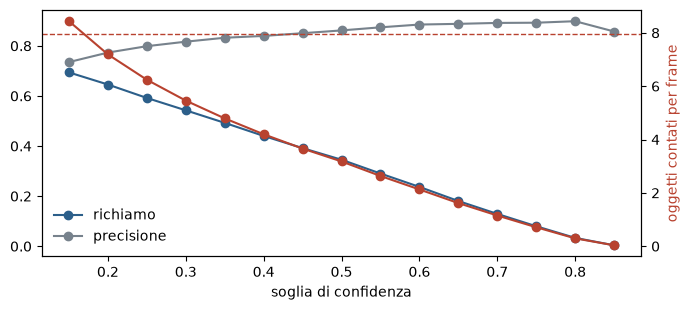

In [11]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pathlib, urllib.request, zipfile, io
D = pathlib.Path("dati-video")
if not (D / "clip.mp4").exists():
    U = "https://github.com/nunziati/zcs-ai-course-2026/releases/download/dati-video/8calves-clip.zip"
    with urllib.request.urlopen(U) as r: zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)
# PUNTO DI VARIAZIONE
# yolo11n, yolo11s, yolo11m (AGPL-3.0)   oppure   rtdetr (Apache 2.0)
DETECTOR = "yolo11m"
vera = pd.read_csv(D / "clip-verita.csv")
L, A = 800, 600                                   # larghezza e altezza del frame
vera["x1"] = (vera.x - vera.w / 2) * L; vera["y1"] = (vera.y - vera.h / 2) * A
vera["x2"] = (vera.x + vera.w / 2) * L; vera["y2"] = (vera.y + vera.h / 2) * A
B = ["x1", "y1", "x2", "y2"]
ANIMALI = {"cow", "dog", "bird", "sheep", "bear", "cat", "horse", "elephant", "zebra", "giraffe"}
def iou(a, b):
    """Matrice di intersezione su unione fra due insiemi di bounding box (x1, y1, x2, y2)."""
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    dentro = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    aa = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]); bb = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return dentro / (aa[:, None] + bb[None, :] - dentro + 1e-9)
INK, MUTED, BLU, ROS = "#1f2933", "#77828c", "#2c5f8a", "#b8422f"

# PUNTO DI VARIAZIONE
SOGLIA_DI_ESERCIZIO = 0.40

det = pd.read_csv(D / ("det-" + DETECTOR + ".csv"))
det = det[det.classe.isin(ANIMALI)]
nf = vera.frame.nunique(); veri_per_frame = len(vera) / nf

def misura(soglia):
    d = det[det.conf >= soglia]
    tp = fp = ng = nb = 0
    for f, v in vera.groupby("frame"):
        b = d[d.frame == f][B].values; nb += len(b); g = v[B].values; ng += len(g)
        if len(b):
            m = iou(g, b); tp += int((m.max(1) >= 0.5).sum()); fp += int((m.max(0) < 0.5).sum())
    return tp / ng, tp / max(tp + fp, 1), nb / nf

soglie = np.arange(0.15, 0.86, 0.05)
r, p, n = zip(*[misura(s) for s in soglie])
print(f"detector: {DETECTOR}, oggetti veri per frame: {veri_per_frame:.1f}")
print(f"\n{'soglia':>8}{'richiamo':>11}{'precisione':>13}{'contati/frame':>16}")
for s, a, b, q in zip(soglie, r, p, n):
    marca = "  <-- soglia di esercizio" if abs(s - SOGLIA_DI_ESERCIZIO) < 0.025 else ""
    print(f"{s:8.2f}{a:11.2f}{b:13.2f}{q:16.1f}{marca}")
n = np.array(n); k = int(np.argmin(np.abs(n - veri_per_frame)))
if n.max() >= veri_per_frame >= n.min():
    print(f"\nIl conteggio raggiunge il valore vero intorno a {soglie[k]:.2f}, dove la precisione")
    print(f"vale {p[k]:.2f} e il richiamo {r[k]:.2f}: il numero e' giusto perche' gli oggetti mancati")
    print("e quelli inventati si compensano, non perche' il sistema li abbia trovati tutti.")
    print("Un conteggio corretto non dimostra che le detection lo siano.")
else:
    print(f"\nCon questo detector il conteggio non arriva mai a {veri_per_frame:.1f}: il massimo e'")
    print(f"{n.max():.1f} alla soglia piu' bassa. Nessuna soglia rende il conteggio corretto,")
    print("perche' il richiamo non basta: la soglia sposta il punto di equilibrio fra oggetti")
    print("mancati e oggetti inventati, e non lo elimina.")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(soglie, r, "o-", color=BLU, label="richiamo")
ax.plot(soglie, p, "o-", color=MUTED, label="precisione")
ax2 = ax.twinx()
ax2.plot(soglie, n, "o-", color=ROS, label="contati per frame")
ax2.axhline(veri_per_frame, ls="--", lw=1, color=ROS)
ax.set_xlabel("soglia di confidenza"); ax2.set_ylabel("oggetti contati per frame", color=ROS)
ax.legend(frameon=False, loc="lower left"); fig.tight_layout(); plt.show()

## 12 · Il punteggio non e' una probabilita'

Confronto fra il punteggio dichiarato e la frazione di predizioni che risultano corrette.


detector: yolo11m

  fascia di punteggio  predizioni   punteggio medio   frazione corretta
            0.1 - 0.2        1753             0.144               0.272
            0.2 - 0.3        1039             0.247               0.472
            0.3 - 0.4         757             0.348               0.639
            0.4 - 0.5         611             0.449               0.740
            0.5 - 0.6         629             0.549               0.811
            0.6 - 0.7         586             0.648               0.877
            0.7 - 0.8         515             0.750               0.889
            0.8 - 0.9         177             0.827               0.898

scarto medio fra punteggio dichiarato e frazione corretta: 0.205
Il punteggio ordina bene le predizioni e non vale come probabilita'. Una soglia
scelta leggendolo come una probabilita' non produce l'errore atteso.


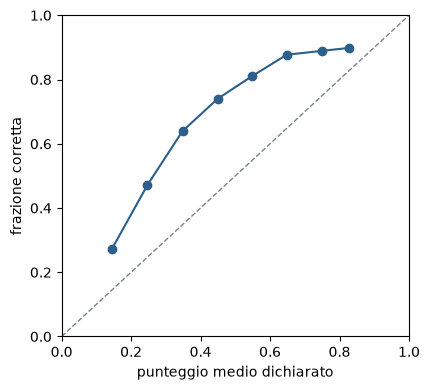

In [12]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pathlib, urllib.request, zipfile, io
D = pathlib.Path("dati-video")
if not (D / "clip.mp4").exists():
    U = "https://github.com/nunziati/zcs-ai-course-2026/releases/download/dati-video/8calves-clip.zip"
    with urllib.request.urlopen(U) as r: zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)
# PUNTO DI VARIAZIONE
# yolo11n, yolo11s, yolo11m (AGPL-3.0)   oppure   rtdetr (Apache 2.0)
DETECTOR = "yolo11m"
vera = pd.read_csv(D / "clip-verita.csv")
L, A = 800, 600                                   # larghezza e altezza del frame
vera["x1"] = (vera.x - vera.w / 2) * L; vera["y1"] = (vera.y - vera.h / 2) * A
vera["x2"] = (vera.x + vera.w / 2) * L; vera["y2"] = (vera.y + vera.h / 2) * A
B = ["x1", "y1", "x2", "y2"]
ANIMALI = {"cow", "dog", "bird", "sheep", "bear", "cat", "horse", "elephant", "zebra", "giraffe"}
def iou(a, b):
    """Matrice di intersezione su unione fra due insiemi di bounding box (x1, y1, x2, y2)."""
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    dentro = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    aa = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]); bb = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return dentro / (aa[:, None] + bb[None, :] - dentro + 1e-9)
INK, MUTED, BLU, ROS = "#1f2933", "#77828c", "#2c5f8a", "#b8422f"

det = pd.read_csv(D / ("det-" + DETECTOR + ".csv"))
det = det[det.classe.isin(ANIMALI)].sort_values("conf", ascending=False).copy()

preso = {f: np.zeros(len(v), bool) for f, v in vera.groupby("frame")}
gt = {f: v[B].values for f, v in vera.groupby("frame")}
ok = []
for f, x1, y1, x2, y2 in det[["frame", "x1", "y1", "x2", "y2"]].itertuples(index=False):
    m = iou(np.array([[x1, y1, x2, y2]]), gt[f])[0]
    m = np.where(preso[f], -1, m); k = int(m.argmax())
    if m[k] >= 0.5: preso[f][k] = True; ok.append(1)
    else: ok.append(0)
det["corretta"] = ok

bordi = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
print(f"detector: {DETECTOR}")
print(f"\n{'fascia di punteggio':>21}{'predizioni':>12}{'punteggio medio':>18}{'frazione corretta':>20}")
mx, my = [], []
for a, b in zip(bordi[:-1], bordi[1:]):
    s = det[(det.conf >= a) & (det.conf < b)]
    if len(s) < 20: continue
    mx.append(s.conf.mean()); my.append(s.corretta.mean())
    print(f"{f'{a:.1f} - {b:.1f}':>21}{len(s):12d}{s.conf.mean():18.3f}{s.corretta.mean():20.3f}")
scarto = float(np.mean([abs(a - b) for a, b in zip(mx, my)]))
print(f"\nscarto medio fra punteggio dichiarato e frazione corretta: {scarto:.3f}")
print("Il punteggio ordina bene le predizioni e non vale come probabilita'. Una soglia")
print("scelta leggendolo come una probabilita' non produce l'errore atteso.")

fig, ax = plt.subplots(figsize=(4.4, 4.0))
ax.plot([0, 1], [0, 1], ls="--", lw=1, color=MUTED)
ax.plot(mx, my, "o-", color=BLU)
ax.set_xlabel("punteggio medio dichiarato"); ax.set_ylabel("frazione corretta")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); fig.tight_layout(); plt.show()

## 13 · Telecamera fissa: sottrazione dello sfondo

Con la telecamera ferma, la mediana temporale e' un modello dello sfondo.


sfondo costruito su 60 frame in 161 ms


tempo per frame: 2.2 ms
regioni contate per frame: mediana 5, fra 2 e 9
oggetti veri per frame: 8.0

Costa due ordini di grandezza meno di una rete e non distingue le classi, non
separa due oggetti che si toccano e non sopravvive a una telecamera che si muove
o a un cambio di illuminazione.


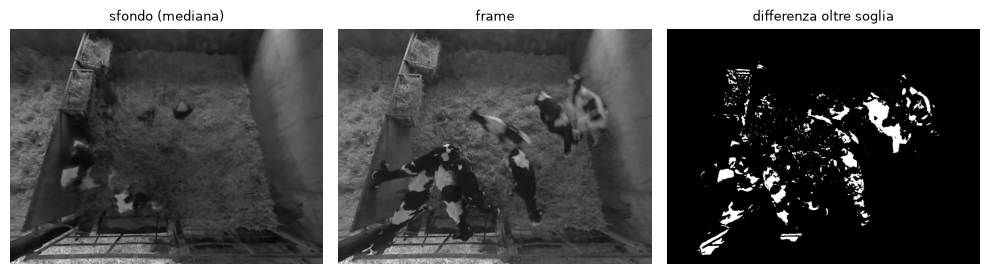

In [13]:
import numpy as np, pandas as pd, cv2, time, matplotlib.pyplot as plt
import pathlib, urllib.request, zipfile, io
D = pathlib.Path("dati-video")
if not (D / "clip.mp4").exists():
    U = "https://github.com/nunziati/zcs-ai-course-2026/releases/download/dati-video/8calves-clip.zip"
    with urllib.request.urlopen(U) as r: zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)
vera = pd.read_csv(D / "clip-verita.csv")
L, A = 800, 600                                   # larghezza e altezza del frame
vera["x1"] = (vera.x - vera.w / 2) * L; vera["y1"] = (vera.y - vera.h / 2) * A
vera["x2"] = (vera.x + vera.w / 2) * L; vera["y2"] = (vera.y + vera.h / 2) * A
B = ["x1", "y1", "x2", "y2"]
INK, MUTED, BLU, ROS = "#1f2933", "#77828c", "#2c5f8a", "#b8422f"

c = cv2.VideoCapture(str(D / "clip.mp4"))
frame = []
while True:
    ok, im = c.read()
    if not ok: break
    frame.append(cv2.cvtColor(im, cv2.COLOR_BGR2GRAY))
c.release()
frame = np.stack(frame)

t0 = time.perf_counter()
sfondo = np.median(frame[::10], axis=0).astype(np.uint8)
t_sfondo = time.perf_counter() - t0
print(f"sfondo costruito su {len(frame[::10])} frame in {t_sfondo * 1000:.0f} ms")

AREA_MINIMA = 900
t, contati = [], []
for im in frame[:100]:
    t0 = time.perf_counter()
    d = cv2.absdiff(im, sfondo)
    _, m = cv2.threshold(d, 40, 255, cv2.THRESH_BINARY)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    n, _, stat, _ = cv2.connectedComponentsWithStats(m)
    contati.append(int((stat[1:, cv2.CC_STAT_AREA] >= AREA_MINIMA).sum()))
    t.append(time.perf_counter() - t0)

veri = len(vera) / vera.frame.nunique()
print(f"tempo per frame: {np.median(t) * 1000:.1f} ms")
print(f"regioni contate per frame: mediana {np.median(contati):.0f}, "
      f"fra {min(contati)} e {max(contati)}")
print(f"oggetti veri per frame: {veri:.1f}")
print("\nCosta due ordini di grandezza meno di una rete e non distingue le classi, non")
print("separa due oggetti che si toccano e non sopravvive a una telecamera che si muove")
print("o a un cambio di illuminazione.")

fig, ax = plt.subplots(1, 3, figsize=(10, 2.8))
ax[0].imshow(sfondo, cmap="gray"); ax[0].set_title("sfondo (mediana)", fontsize=9)
ax[1].imshow(frame[50], cmap="gray"); ax[1].set_title("frame", fontsize=9)
d = cv2.absdiff(frame[50], sfondo)
ax[2].imshow(d > 40, cmap="gray"); ax[2].set_title("differenza oltre soglia", fontsize=9)
for a in ax: a.axis("off")
fig.tight_layout(); plt.show()

## 14 · Filtro di Kalman: predizione e correzione

Una traccia vera, misurata con rumore e interrotta per un secondo.


dove la misura c'e':
  errore medio della misura grezza       7.3 px
  errore medio della stima filtrata      6.5 px

nei venti frame senza misura, errore della sola predizione:
  al primo frame    12.8 px
  a meta'           90.7 px
  all'ultimo       208.6 px

Con la misura il filtro corregge e l'errore scende sotto quello della misura
grezza. Senza, resta la sola predizione, e l'errore cresce con il tempo di assenza:
e' la predizione a mantenere la traccia attraverso un'occlusione breve, ed e' sempre
lei a perderla se l'occlusione dura.


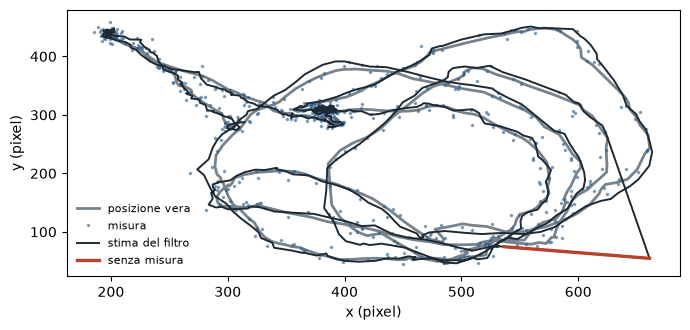

In [14]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pathlib, urllib.request, zipfile, io
D = pathlib.Path("dati-video")
if not (D / "clip.mp4").exists():
    U = "https://github.com/nunziati/zcs-ai-course-2026/releases/download/dati-video/8calves-clip.zip"
    with urllib.request.urlopen(U) as r: zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)
vera = pd.read_csv(D / "clip-verita.csv")
L, A = 800, 600                                   # larghezza e altezza del frame
vera["x1"] = (vera.x - vera.w / 2) * L; vera["y1"] = (vera.y - vera.h / 2) * A
vera["x2"] = (vera.x + vera.w / 2) * L; vera["y2"] = (vera.y + vera.h / 2) * A
B = ["x1", "y1", "x2", "y2"]
INK, MUTED, BLU, ROS = "#1f2933", "#77828c", "#2c5f8a", "#b8422f"

t = vera[vera.tracklet_id == 3].sort_values("frame")
z = np.stack([t.x.values * L, t.y.values * A], 1)          # centro vero
rng = np.random.default_rng(0)
mis = z + rng.normal(0, 6.0, z.shape)                      # misura rumorosa
BUCO = slice(120, 140)                                     # un secondo senza detection

F = np.array([[1,0,1,0],[0,1,0,1],[0,0,1,0],[0,0,0,1]], float)   # posizione e velocita'
H = np.array([[1,0,0,0],[0,1,0,0]], float)
Q = np.eye(4) * 0.6; R = np.eye(2) * 36.0
x = np.array([mis[0,0], mis[0,1], 0, 0], float); P = np.eye(4) * 100

stima, predetto = [], []
for k in range(len(mis)):
    x = F @ x; P = F @ P @ F.T + Q                          # predizione
    predetto.append(x[:2].copy())
    if not (BUCO.start <= k < BUCO.stop):                   # correzione, se c'e' la misura
        y = mis[k] - H @ x
        S = H @ P @ H.T + R; K = P @ H.T @ np.linalg.inv(S)
        x = x + K @ y; P = (np.eye(4) - K @ H) @ P
    stima.append(x[:2].copy())
stima = np.array(stima); predetto = np.array(predetto)

con = np.ones(len(z), bool); con[BUCO] = False
e_misura = float(np.linalg.norm(mis[con] - z[con], axis=1).mean())
e_stima = float(np.linalg.norm(stima[con] - z[con], axis=1).mean())
crescita = np.linalg.norm(stima[BUCO] - z[BUCO], axis=1)
print(f"dove la misura c'e':")
print(f"  errore medio della misura grezza    {e_misura:6.1f} px")
print(f"  errore medio della stima filtrata   {e_stima:6.1f} px")
print(f"\nnei venti frame senza misura, errore della sola predizione:")
print(f"  al primo frame  {crescita[0]:6.1f} px")
print(f"  a meta'         {crescita[len(crescita) // 2]:6.1f} px")
print(f"  all'ultimo      {crescita[-1]:6.1f} px")
print("\nCon la misura il filtro corregge e l'errore scende sotto quello della misura")
print("grezza. Senza, resta la sola predizione, e l'errore cresce con il tempo di assenza:")
print("e' la predizione a mantenere la traccia attraverso un'occlusione breve, ed e' sempre")
print("lei a perderla se l'occlusione dura.")

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(z[:,0], z[:,1], lw=2, color=MUTED, label="posizione vera")
ax.plot(mis[:,0], mis[:,1], ".", ms=3, color=BLU, alpha=.5, label="misura")
ax.plot(stima[:,0], stima[:,1], lw=1.4, color=INK, label="stima del filtro")
ax.plot(stima[BUCO,0], stima[BUCO,1], lw=2.4, color=ROS, label="senza misura")
ax.set_xlabel("x (pixel)"); ax.set_ylabel("y (pixel)"); ax.legend(frameon=False, fontsize=8)
fig.tight_layout(); plt.show()

## 15 · Matrice di costo e assegnamento

Associare le predizioni alle detection del frame nuovo: uno per uno, al costo minimo.


In [15]:
import numpy as np, pandas as pd
from scipy.optimize import linear_sum_assignment
import pathlib, urllib.request, zipfile, io
D = pathlib.Path("dati-video")
if not (D / "clip.mp4").exists():
    U = "https://github.com/nunziati/zcs-ai-course-2026/releases/download/dati-video/8calves-clip.zip"
    with urllib.request.urlopen(U) as r: zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)
# PUNTO DI VARIAZIONE
# yolo11n, yolo11s, yolo11m (AGPL-3.0)   oppure   rtdetr (Apache 2.0)
DETECTOR = "yolo11m"
vera = pd.read_csv(D / "clip-verita.csv")
L, A = 800, 600                                   # larghezza e altezza del frame
vera["x1"] = (vera.x - vera.w / 2) * L; vera["y1"] = (vera.y - vera.h / 2) * A
vera["x2"] = (vera.x + vera.w / 2) * L; vera["y2"] = (vera.y + vera.h / 2) * A
B = ["x1", "y1", "x2", "y2"]
ANIMALI = {"cow", "dog", "bird", "sheep", "bear", "cat", "horse", "elephant", "zebra", "giraffe"}
def iou(a, b):
    """Matrice di intersezione su unione fra due insiemi di bounding box (x1, y1, x2, y2)."""
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    dentro = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    aa = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]); bb = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return dentro / (aa[:, None] + bb[None, :] - dentro + 1e-9)

det = pd.read_csv(D / ("det-" + DETECTOR + ".csv"))
det = det[det.classe.isin(ANIMALI) & (det.conf >= 0.35)]
F0, F1 = 100, 101
a = det[det.frame == F0][B].values
b = det[det.frame == F1][B].values
M = iou(a, b)

print(f"frame {F0}: {len(a)} bounding box     frame {F1}: {len(b)} bounding box")
print("\nmatrice di sovrapposizione (righe: frame prima, colonne: frame dopo)")
print("      " + "".join(f"{j:7d}" for j in range(len(b))))
for i, riga in enumerate(M):
    print(f"  {i:3d} " + "".join(f"{v:7.2f}" for v in riga))

r, q = linear_sum_assignment(-M)
tenuti = [(i, j) for i, j in zip(r, q) if M[i, j] >= 0.3]
print(f"\nassegnamento al costo minimo, sovrapposizione minima 0,30:")
for i, j in tenuti:
    print(f"  riga {i} -> colonna {j}   sovrapposizione {M[i, j]:.2f}")

def golosa(M, iou_min=0.3):
    """Prende il miglior abbinamento disponibile, uno alla volta."""
    coppie, usate_r, usate_c = [], set(), set()
    for i, j in zip(*np.unravel_index(np.argsort(-M, axis=None), M.shape)):
        if M[i, j] < iou_min: break
        if i in usate_r or j in usate_c: continue
        coppie.append((i, j)); usate_r.add(i); usate_c.add(j)
    return coppie

def ottima(M, iou_min=0.3):
    r, q = linear_sum_assignment(-M)
    return [(i, j) for i, j in zip(r, q) if M[i, j] >= iou_min]

NF = int(det.frame.max()) + 1
print(f"\nquanto spesso le due scelte differiscono, al crescere del salto fra i due frame")
print(f"\n{'salto':>7}{'coppie':>9}{'differenti':>13}{'guadagno medio':>17}")
for salto in (1, 2, 5, 10, 20):
    diverse = 0; guadagno = 0.0; coppie = 0
    for f in range(NF - salto):
        a2 = det[det.frame == f][B].values; b2 = det[det.frame == f + salto][B].values
        if not len(a2) or not len(b2): continue
        coppie += 1
        M2 = iou(a2, b2)
        so = sum(M2[i, j] for i, j in ottima(M2)); sg = sum(M2[i, j] for i, j in golosa(M2))
        if so - sg > 1e-6: diverse += 1; guadagno += so - sg
    m = guadagno / diverse if diverse else 0.0
    print(f"{salto:7d}{coppie:9d}{diverse:13d}{m:17.3f}")

# quante volte una detection e' credibile per piu' di un bounding box del frame prima
contesa = 0; confronti = 0
for f in range(NF - 1):
    a2 = det[det.frame == f][B].values; b2 = det[det.frame == f + 1][B].values
    if not len(a2) or not len(b2): continue
    M2 = iou(a2, b2); confronti += 1
    contesa += int(((M2 >= 0.3).sum(axis=0) > 1).any())
print(f"\nframe in cui almeno una detection e' credibile per due bounding box diversi: "
      f"{contesa} su {confronti}")
print("\nLa scelta golosa prende l'abbinamento migliore per primo e lascia agli altri")
print("quello che resta; l'assegnamento sceglie l'insieme, e non puo' fare peggio. Su questa")
print("clip le due non differiscono mai: la contesa fra due bounding box per la stessa")
print("detection compare in qualche decina di frame, e non e' mai cosi' stretta da cambiare")
print("l'esito. Con otto animali distanti fra loro il problema e' facile. L'assegnamento")
print("serve in una scena affollata, il suo costo e' trascurabile, e la differenza fra i")
print("due, dove compare, e' uno scambio di identita'.")

frame 100: 5 bounding box     frame 101: 4 bounding box

matrice di sovrapposizione (righe: frame prima, colonne: frame dopo)
            0      1      2      3
    0    0.78   0.00   0.00   0.00
    1    0.00   0.03   0.78   0.00
    2    0.00   0.00   0.00   0.94
    3    0.00   0.00   0.00   0.00
    4    0.00   0.00   0.00   0.08

assegnamento al costo minimo, sovrapposizione minima 0,30:
  riga 0 -> colonna 0   sovrapposizione 0.78
  riga 1 -> colonna 2   sovrapposizione 0.78
  riga 2 -> colonna 3   sovrapposizione 0.94

quanto spesso le due scelte differiscono, al crescere del salto fra i due frame

  salto   coppie   differenti   guadagno medio


      1      595            4            0.002


      2      594            6            0.002


      5      591            2            0.001


     10      586            1            0.233


     20      576            1            0.000



frame in cui almeno una detection e' credibile per due bounding box diversi: 94 su 595

La scelta golosa prende l'abbinamento migliore per primo e lascia agli altri
quello che resta; l'assegnamento sceglie l'insieme, e non puo' fare peggio. Su questa
clip le due non differiscono mai: la contesa fra due bounding box per la stessa
detection compare in qualche decina di frame, e non e' mai cosi' stretta da cambiare
l'esito. Con otto animali distanti fra loro il problema e' facile. L'assegnamento
serve in una scena affollata, il suo costo e' trascurabile, e la differenza fra i
due, dove compare, e' uno scambio di identita'.


## 16 · SORT e ByteTrack, sulle stesse detection

Lo stesso predittore. Cambia solo il trattamento delle detection a punteggio basso.


In [16]:
import numpy as np, pandas as pd
from scipy.optimize import linear_sum_assignment
import pathlib, urllib.request, zipfile, io
D = pathlib.Path("dati-video")
if not (D / "clip.mp4").exists():
    U = "https://github.com/nunziati/zcs-ai-course-2026/releases/download/dati-video/8calves-clip.zip"
    with urllib.request.urlopen(U) as r: zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)
# PUNTO DI VARIAZIONE
# yolo11n, yolo11s, yolo11m (AGPL-3.0)   oppure   rtdetr (Apache 2.0)
DETECTOR = "yolo11m"
vera = pd.read_csv(D / "clip-verita.csv")
L, A = 800, 600                                   # larghezza e altezza del frame
vera["x1"] = (vera.x - vera.w / 2) * L; vera["y1"] = (vera.y - vera.h / 2) * A
vera["x2"] = (vera.x + vera.w / 2) * L; vera["y2"] = (vera.y + vera.h / 2) * A
B = ["x1", "y1", "x2", "y2"]
ANIMALI = {"cow", "dog", "bird", "sheep", "bear", "cat", "horse", "elephant", "zebra", "giraffe"}
def iou(a, b):
    """Matrice di intersezione su unione fra due insiemi di bounding box (x1, y1, x2, y2)."""
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    dentro = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    aa = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]); bb = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return dentro / (aa[:, None] + bb[None, :] - dentro + 1e-9)
def traccia(det, alta=0.5, bassa=0.15, due_passate=False, iou_min=0.3, max_persi=15):
    """Tracking-by-detection. Predizione a velocita' costante, associazione al costo minimo.
    Con due_passate, le detection sotto la soglia alta sono offerte alle tracce rimaste sole."""
    NF = int(det.frame.max()) + 1
    tracce, prossimo, uscita = {}, 1, []

    def associa(ids, pred, box):
        if not len(ids) or not len(box): return [], list(range(len(box))), list(ids)
        M = iou(pred, box)
        r, q = linear_sum_assignment(-M)
        coppie = [(ids[i], j) for i, j in zip(r, q) if M[i, j] >= iou_min]
        liberi = [j for j in range(len(box)) if j not in [c[1] for c in coppie]]
        senza = [i for i in ids if i not in [c[0] for c in coppie]]
        return coppie, liberi, senza

    def aggiorna(i, nb):
        tracce[i]["v"] = 0.6 * tracce[i]["v"] + 0.4 * (nb - tracce[i]["b"])
        tracce[i]["b"] = nb; tracce[i]["persi"] = 0

    for f in range(NF):
        d = det[det.frame == f]
        forti = d[d.conf >= alta][B].values
        deboli = d[(d.conf >= bassa) & (d.conf < alta)][B].values if due_passate else np.zeros((0, 4))
        ids = list(tracce)
        pred = np.array([tracce[i]["b"] + tracce[i]["v"] for i in ids]).reshape(-1, 4)
        coppie, liberi, senza = associa(ids, pred, forti)
        for i, j in coppie: aggiorna(i, forti[j])
        if due_passate and len(deboli) and senza:
            p2 = np.array([tracce[i]["b"] + tracce[i]["v"] for i in senza]).reshape(-1, 4)
            c2, _, senza = associa(senza, p2, deboli)
            for i, j in c2: aggiorna(i, deboli[j])
        for i in senza:
            tracce[i]["persi"] += 1; tracce[i]["b"] = tracce[i]["b"] + tracce[i]["v"]
        for j in liberi:
            tracce[prossimo] = {"b": forti[j], "v": np.zeros(4), "persi": 0}; prossimo += 1
        for i in [i for i in tracce if tracce[i]["persi"] > max_persi]: del tracce[i]
        for i in [i for i in tracce if tracce[i]["persi"] == 0]:
            uscita.append((f, i, *tracce[i]["b"]))
    return pd.DataFrame(uscita, columns=["frame", "id", "x1", "y1", "x2", "y2"])

det = pd.read_csv(D / ("det-" + DETECTOR + ".csv"))
det = det[det.classe.isin(ANIMALI)]

def scambi(tr):
    """Quante volte un oggetto vero cambia l'identita' che gli viene assegnata."""
    ultimo, n, abbinati = {}, 0, 0
    for f, v in vera.groupby("frame"):
        p = tr[tr.frame == f]
        if not len(p): continue
        M = iou(v[B].values, p[B].values)
        r, q = linear_sum_assignment(-M)
        for i, j in zip(r, q):
            if M[i, j] < 0.5: continue
            abbinati += 1
            g = int(v.tracklet_id.values[i]); pid = int(p.id.values[j])
            if g in ultimo and ultimo[g] != pid: n += 1
            ultimo[g] = pid
    return n, abbinati

print(f"detector: {DETECTOR}, {int(det.frame.max()) + 1} frame, otto identita' vere")
print(f"\n{'tracker':>12}{'tracce create':>15}{'abbinamenti':>13}{'scambi di identita':>21}")
esito = {}
for nome, due in (("SORT", False), ("ByteTrack", True)):
    tr = traccia(det, due_passate=due)
    n, ab = scambi(tr)
    esito[nome] = (tr.id.nunique(), ab, n)
    print(f"{nome:>12}{tr.id.nunique():15d}{ab:13d}{n:21d}")

print("\nSORT scarta le detection sotto la soglia alta. ByteTrack le offre, in una seconda")
print("passata, alle sole tracce rimaste senza abbinamento: un oggetto che si oscura perde")
print("punteggio prima di sparire, ed e' li' che la traccia si spezza.")
print("Le tracce create sarebbero otto se nessuna si spezzasse mai.")
t_s, a_s, n_s = esito["SORT"]; t_b, a_b, n_b = esito["ByteTrack"]
print(f"\nQui la seconda passata porta gli abbinamenti da {a_s} a {a_b} e le tracce create da")
print(f"{t_s} a {t_b}.", end=" ")
if n_b < n_s:
    print(f"Gli scambi scendono da {n_s} a {n_b}: le detection deboli erano oggetti veri.")
else:
    print(f"Gli scambi pero' salgono da {n_s} a {n_b}: fra le detection deboli di questo")
    print("detector ci sono abbastanza falsi positivi da sottrarre l'abbinamento a una traccia.")
    print("La seconda passata conviene quando il punteggio basso significa oggetto oscurato,")
    print("e non quando significa oggetto inesistente.")


detector: yolo11m, 600 frame, otto identita' vere

     tracker  tracce create  abbinamenti   scambi di identita


        SORT             84         1641                   81


   ByteTrack             37         2987                   53

SORT scarta le detection sotto la soglia alta. ByteTrack le offre, in una seconda
passata, alle sole tracce rimaste senza abbinamento: un oggetto che si oscura perde
punteggio prima di sparire, ed e' li' che la traccia si spezza.
Le tracce create sarebbero otto se nessuna si spezzasse mai.

Qui la seconda passata porta gli abbinamenti da 1641 a 2987 e le tracce create da
84 a 37. Gli scambi scendono da 81 a 53: le detection deboli erano oggetti veri.


## 17 · MOTA, IDF1 e HOTA

Le stesse tracce, misurate con le tre metriche: misurano cose diverse e non ordinano allo stesso modo.


In [17]:
import numpy as np, pandas as pd
from scipy.optimize import linear_sum_assignment
from collections import Counter
import pathlib, urllib.request, zipfile, io
D = pathlib.Path("dati-video")
if not (D / "clip.mp4").exists():
    U = "https://github.com/nunziati/zcs-ai-course-2026/releases/download/dati-video/8calves-clip.zip"
    with urllib.request.urlopen(U) as r: zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)
# PUNTO DI VARIAZIONE
# yolo11n, yolo11s, yolo11m (AGPL-3.0)   oppure   rtdetr (Apache 2.0)
DETECTOR = "yolo11m"
vera = pd.read_csv(D / "clip-verita.csv")
L, A = 800, 600                                   # larghezza e altezza del frame
vera["x1"] = (vera.x - vera.w / 2) * L; vera["y1"] = (vera.y - vera.h / 2) * A
vera["x2"] = (vera.x + vera.w / 2) * L; vera["y2"] = (vera.y + vera.h / 2) * A
B = ["x1", "y1", "x2", "y2"]
ANIMALI = {"cow", "dog", "bird", "sheep", "bear", "cat", "horse", "elephant", "zebra", "giraffe"}
def iou(a, b):
    """Matrice di intersezione su unione fra due insiemi di bounding box (x1, y1, x2, y2)."""
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    dentro = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    aa = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]); bb = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return dentro / (aa[:, None] + bb[None, :] - dentro + 1e-9)
def traccia(det, alta=0.5, bassa=0.15, due_passate=False, iou_min=0.3, max_persi=15):
    """Tracking-by-detection. Predizione a velocita' costante, associazione al costo minimo.
    Con due_passate, le detection sotto la soglia alta sono offerte alle tracce rimaste sole."""
    NF = int(det.frame.max()) + 1
    tracce, prossimo, uscita = {}, 1, []

    def associa(ids, pred, box):
        if not len(ids) or not len(box): return [], list(range(len(box))), list(ids)
        M = iou(pred, box)
        r, q = linear_sum_assignment(-M)
        coppie = [(ids[i], j) for i, j in zip(r, q) if M[i, j] >= iou_min]
        liberi = [j for j in range(len(box)) if j not in [c[1] for c in coppie]]
        senza = [i for i in ids if i not in [c[0] for c in coppie]]
        return coppie, liberi, senza

    def aggiorna(i, nb):
        tracce[i]["v"] = 0.6 * tracce[i]["v"] + 0.4 * (nb - tracce[i]["b"])
        tracce[i]["b"] = nb; tracce[i]["persi"] = 0

    for f in range(NF):
        d = det[det.frame == f]
        forti = d[d.conf >= alta][B].values
        deboli = d[(d.conf >= bassa) & (d.conf < alta)][B].values if due_passate else np.zeros((0, 4))
        ids = list(tracce)
        pred = np.array([tracce[i]["b"] + tracce[i]["v"] for i in ids]).reshape(-1, 4)
        coppie, liberi, senza = associa(ids, pred, forti)
        for i, j in coppie: aggiorna(i, forti[j])
        if due_passate and len(deboli) and senza:
            p2 = np.array([tracce[i]["b"] + tracce[i]["v"] for i in senza]).reshape(-1, 4)
            c2, _, senza = associa(senza, p2, deboli)
            for i, j in c2: aggiorna(i, deboli[j])
        for i in senza:
            tracce[i]["persi"] += 1; tracce[i]["b"] = tracce[i]["b"] + tracce[i]["v"]
        for j in liberi:
            tracce[prossimo] = {"b": forti[j], "v": np.zeros(4), "persi": 0}; prossimo += 1
        for i in [i for i in tracce if tracce[i]["persi"] > max_persi]: del tracce[i]
        for i in [i for i in tracce if tracce[i]["persi"] == 0]:
            uscita.append((f, i, *tracce[i]["b"]))
    return pd.DataFrame(uscita, columns=["frame", "id", "x1", "y1", "x2", "y2"])

det = pd.read_csv(D / ("det-" + DETECTOR + ".csv"))
det = det[det.classe.isin(ANIMALI)]
NF = int(det.frame.max()) + 1

def metriche(tr):
    fn = fp = idsw = tp = 0
    ultimo, insieme = {}, Counter()
    n_vero, n_pred = Counter(), Counter()
    for f in range(NF):
        v = vera[vera.frame == f]; p = tr[tr.frame == f]
        n_vero.update(v.tracklet_id.tolist()); n_pred.update(p.id.tolist())
        ab = []
        if len(v) and len(p):
            M = iou(v[B].values, p[B].values)
            r, q = linear_sum_assignment(-M)
            ab = [(i, j) for i, j in zip(r, q) if M[i, j] >= 0.5]
        tp += len(ab); fn += len(v) - len(ab); fp += len(p) - len(ab)
        for i, j in ab:
            g = int(v.tracklet_id.values[i]); pid = int(p.id.values[j])
            insieme[(g, pid)] += 1
            if g in ultimo and ultimo[g] != pid: idsw += 1
            ultimo[g] = pid

    mota = 1 - (fn + fp + idsw) / len(vera)
    gs, ps = sorted(n_vero), sorted(n_pred)
    C = np.zeros((len(gs), len(ps)))
    for (g, pid), n in insieme.items(): C[gs.index(g), ps.index(pid)] = n
    r, q = linear_sum_assignment(-C)
    idf1 = 2 * float(C[r, q].sum()) / (len(vera) + len(tr))
    deta = tp / (tp + fn + fp)
    # associazione: per quanti frame quella coppia di identita' resta abbinata
    assa = sum(n * n / (n_vero[g] + n_pred[pid] - n) for (g, pid), n in insieme.items()) / max(tp, 1)
    return dict(MOTA=mota, IDF1=idf1, HOTA=float(np.sqrt(deta * assa)), DetA=deta, AssA=assa,
                FN=fn, FP=fp, IDSW=idsw, tracce=tr.id.nunique())

print(f"detector: {DETECTOR}, otto identita' vere, {NF} frame, sovrapposizione 0,50")
print(f"\n{'tracker':>12}{'MOTA':>8}{'IDF1':>8}{'HOTA':>8}{'DetA':>8}{'AssA':>8}"
      f"{'FN':>7}{'FP':>7}{'scambi':>8}{'tracce':>8}")
esito = {}
for nome, due in (("SORT", False), ("ByteTrack", True)):
    m = esito[nome] = metriche(traccia(det, due_passate=due))
    print(f"{nome:>12}{m['MOTA']:8.3f}{m['IDF1']:8.3f}{m['HOTA']:8.3f}{m['DetA']:8.3f}"
          f"{m['AssA']:8.3f}{m['FN']:7d}{m['FP']:7d}{m['IDSW']:8d}{m['tracce']:8d}")
a, b = esito["SORT"], esito["ByteTrack"]
print(f"\nguadagno di ByteTrack su SORT:  MOTA {b['MOTA'] - a['MOTA']:+.3f}   "
      f"IDF1 {b['IDF1'] - a['IDF1']:+.3f}   HOTA {b['HOTA'] - a['HOTA']:+.3f}")
print(f"scomposto:  trovare (DetA) {b['DetA'] / a['DetA']:.1f} volte,   "
      f"associare (AssA) {b['AssA'] / a['AssA']:.1f} volte")
delta = {k: b[k] - a[k] for k in ("MOTA", "IDF1", "HOTA")}
segni = [np.sign(v) for v in delta.values()]
ampiezze = [abs(v) for v in delta.values()]
print("\nMOTA conta gli errori uno per uno e li pesa uguale, quindi lo dominano i falsi")
print("negativi e uno scambio di identita' gli costa quanto una detection mancata. IDF1")
print("guarda quanto a lungo un'identita' resta la stessa. HOTA tiene separati il trovare")
print("e l'associare. Qui e' calcolata alla sola soglia 0,50 invece che sulla media di")
print("tutte, come vuole la definizione.")
rapporto = max(ampiezze) / max(min(ampiezze), 1e-9)
if len(set(segni)) > 1:
    print("\nSu queste tracce le tre metriche indicano vincitori diversi. Scegliere il tracker")
    print("guardando una sola di queste metriche porta a decisioni opposte, sugli stessi dati.")
elif rapporto > 5:
    forte = max(delta, key=lambda k: abs(delta[k])); debole = min(delta, key=lambda k: abs(delta[k]))
    print(f"\nSu queste tracce le tre metriche indicano lo stesso vincitore, con forza")
    print(f"molto diversa: {forte} si sposta di {delta[forte]:+.3f} e {debole} di {delta[debole]:+.3f},")
    print(f"un fattore {rapporto:.0f}. Il tracker che associa meglio produce anche piu' falsi")
    print("positivi: MOTA li conta uno per uno, HOTA li divide fra le due componenti. Un")
    print("rapporto e' 'molto meglio' o 'uguale' secondo quale numero riporta.")
else:
    print("\nSu queste tracce le tre metriche concordano su quale tracker sia migliore e")
    print("all'incirca su quanto. La scomposizione dice dove sta il guadagno.")


detector: yolo11m, otto identita' vere, 600 frame, sovrapposizione 0,50

     tracker    MOTA    IDF1    HOTA    DetA    AssA     FN     FP  scambi  tracce


        SORT   0.271   0.243   0.204   0.325   0.128   3135    266      81      84


   ByteTrack   0.469   0.459   0.411   0.546   0.309   1789    694      53      37

guadagno di ByteTrack su SORT:  MOTA +0.198   IDF1 +0.215   HOTA +0.206
scomposto:  trovare (DetA) 1.7 volte,   associare (AssA) 2.4 volte

MOTA conta gli errori uno per uno e li pesa uguale, quindi lo dominano i falsi
negativi e uno scambio di identita' gli costa quanto una detection mancata. IDF1
guarda quanto a lungo un'identita' resta la stessa. HOTA tiene separati il trovare
e l'associare. Qui e' calcolata alla sola soglia 0,50 invece che sulla media di
tutte, come vuole la definizione.

Su queste tracce le tre metriche concordano su quale tracker sia migliore e
all'incirca su quanto. La scomposizione dice dove sta il guadagno.


## 18 · Dall'oggetto all'evento: il conteggio

Quante identita' distinte attraversano una linea, e quanto quel numero risente delle tracce spezzate.


In [18]:
import numpy as np, pandas as pd
from scipy.optimize import linear_sum_assignment
import pathlib, urllib.request, zipfile, io
D = pathlib.Path("dati-video")
if not (D / "clip.mp4").exists():
    U = "https://github.com/nunziati/zcs-ai-course-2026/releases/download/dati-video/8calves-clip.zip"
    with urllib.request.urlopen(U) as r: zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)
# PUNTO DI VARIAZIONE
# yolo11n, yolo11s, yolo11m (AGPL-3.0)   oppure   rtdetr (Apache 2.0)
DETECTOR = "yolo11m"
vera = pd.read_csv(D / "clip-verita.csv")
L, A = 800, 600                                   # larghezza e altezza del frame
vera["x1"] = (vera.x - vera.w / 2) * L; vera["y1"] = (vera.y - vera.h / 2) * A
vera["x2"] = (vera.x + vera.w / 2) * L; vera["y2"] = (vera.y + vera.h / 2) * A
B = ["x1", "y1", "x2", "y2"]
ANIMALI = {"cow", "dog", "bird", "sheep", "bear", "cat", "horse", "elephant", "zebra", "giraffe"}
def iou(a, b):
    """Matrice di intersezione su unione fra due insiemi di bounding box (x1, y1, x2, y2)."""
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    dentro = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    aa = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]); bb = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return dentro / (aa[:, None] + bb[None, :] - dentro + 1e-9)
def traccia(det, alta=0.5, bassa=0.15, due_passate=False, iou_min=0.3, max_persi=15):
    """Tracking-by-detection. Predizione a velocita' costante, associazione al costo minimo.
    Con due_passate, le detection sotto la soglia alta sono offerte alle tracce rimaste sole."""
    NF = int(det.frame.max()) + 1
    tracce, prossimo, uscita = {}, 1, []

    def associa(ids, pred, box):
        if not len(ids) or not len(box): return [], list(range(len(box))), list(ids)
        M = iou(pred, box)
        r, q = linear_sum_assignment(-M)
        coppie = [(ids[i], j) for i, j in zip(r, q) if M[i, j] >= iou_min]
        liberi = [j for j in range(len(box)) if j not in [c[1] for c in coppie]]
        senza = [i for i in ids if i not in [c[0] for c in coppie]]
        return coppie, liberi, senza

    def aggiorna(i, nb):
        tracce[i]["v"] = 0.6 * tracce[i]["v"] + 0.4 * (nb - tracce[i]["b"])
        tracce[i]["b"] = nb; tracce[i]["persi"] = 0

    for f in range(NF):
        d = det[det.frame == f]
        forti = d[d.conf >= alta][B].values
        deboli = d[(d.conf >= bassa) & (d.conf < alta)][B].values if due_passate else np.zeros((0, 4))
        ids = list(tracce)
        pred = np.array([tracce[i]["b"] + tracce[i]["v"] for i in ids]).reshape(-1, 4)
        coppie, liberi, senza = associa(ids, pred, forti)
        for i, j in coppie: aggiorna(i, forti[j])
        if due_passate and len(deboli) and senza:
            p2 = np.array([tracce[i]["b"] + tracce[i]["v"] for i in senza]).reshape(-1, 4)
            c2, _, senza = associa(senza, p2, deboli)
            for i, j in c2: aggiorna(i, deboli[j])
        for i in senza:
            tracce[i]["persi"] += 1; tracce[i]["b"] = tracce[i]["b"] + tracce[i]["v"]
        for j in liberi:
            tracce[prossimo] = {"b": forti[j], "v": np.zeros(4), "persi": 0}; prossimo += 1
        for i in [i for i in tracce if tracce[i]["persi"] > max_persi]: del tracce[i]
        for i in [i for i in tracce if tracce[i]["persi"] == 0]:
            uscita.append((f, i, *tracce[i]["b"]))
    return pd.DataFrame(uscita, columns=["frame", "id", "x1", "y1", "x2", "y2"])

det = pd.read_csv(D / ("det-" + DETECTOR + ".csv"))
det = det[det.classe.isin(ANIMALI)]
X_LINEA = 400.0

def attraversamenti(d, colonna_id):
    n = 0
    for _, g in d.sort_values("frame").groupby(colonna_id):
        c = g.cx.values
        n += int(((c[:-1] - X_LINEA) * (c[1:] - X_LINEA) < 0).sum())
    return n

veri = attraversamenti(vera.assign(cx=vera.x * L), "tracklet_id")
print(f"linea verticale a x = {X_LINEA:.0f} px")
print(f"attraversamenti veri: {veri}")
print(f"\n{'tracker':>12}{'soglia alta':>13}{'tracce':>9}{'attraversamenti':>18}{'errore':>9}")
for nome, due in (("SORT", False), ("ByteTrack", True)):
    for alta in (0.35, 0.50):
        tr = traccia(det, alta=alta, due_passate=due)
        tr = tr.assign(cx=(tr.x1 + tr.x2) / 2)
        n = attraversamenti(tr, "id")
        print(f"{nome:>12}{alta:13.2f}{tr.id.nunique():9d}{n:18d}{n - veri:+9d}")
print("\nIl conteggio finale misura la pipeline intera, e fra il detector e il numero c'e'")
print("il tracking. Una traccia che si spezza mentre l'oggetto e' sulla linea fa contare due")
print("volte lo stesso passaggio; una traccia che muore prima della linea non lo conta")
print("affatto. I due errori non si compensano in modo prevedibile.")


linea verticale a x = 400 px
attraversamenti veri: 30

     tracker  soglia alta   tracce   attraversamenti   errore


        SORT         0.35      118                37       +7


        SORT         0.50       84                23       -7


   ByteTrack         0.35       82                51      +21


   ByteTrack         0.50       37                48      +18

Il conteggio finale misura la pipeline intera, e fra il detector e il numero c'e'
il tracking. Una traccia che si spezza mentre l'oggetto e' sulla linea fa contare due
volte lo stesso passaggio; una traccia che muore prima della linea non lo conta
affatto. I due errori non si compensano in modo prevedibile.


## 19 · Tempo per stadio

Dove va il tempo di un frame: decodifica, preprocessing, inferenza, post-processing.


detector: yolo11m, 40 frame, ingresso 640

            stadio   ms mediani    quota
        decodifica          0.8     0.6%   
     preprocessing          1.5     1.3%   
         inferenza        116.7    97.9%   #######################################
   post-processing          0.3     0.2%   
            totale        119.2     100%

frequenza sostenibile: 8.4 frame al secondo

Lo stadio dominante determina dove conviene intervenire: ridurre il modello quando
il tempo se ne va nella decodifica non cambia il risultato, e viceversa.
Questa ripartizione vale per questa configurazione e non e' generale. Qui il video e'
800x600 e il modello gira sulla CPU, quindi l'inferenza domina. Con un modello
su GPU e uno stream ad alta risoluzione le due voci si invertono, e la decodifica
diventa lo stadio dominante. E' il motivo per cui la misura deve essere ripetuta
sulla configurazione di destinazione, invece di essere ereditata da un'altra.


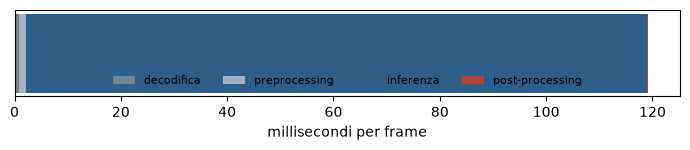

In [19]:
import numpy as np, pandas as pd, cv2, time, matplotlib.pyplot as plt
import pathlib, urllib.request, zipfile, io
D = pathlib.Path("dati-video")
if not (D / "clip.mp4").exists():
    U = "https://github.com/nunziati/zcs-ai-course-2026/releases/download/dati-video/8calves-clip.zip"
    with urllib.request.urlopen(U) as r: zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)
# PUNTO DI VARIAZIONE
# yolo11n, yolo11s, yolo11m (AGPL-3.0)   oppure   rtdetr (Apache 2.0)
DETECTOR = "yolo11m"
ANIMALI = {"cow", "dog", "bird", "sheep", "bear", "cat", "horse", "elephant", "zebra", "giraffe"}
def iou(a, b):
    """Matrice di intersezione su unione fra due insiemi di bounding box (x1, y1, x2, y2)."""
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    dentro = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    aa = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]); bb = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return dentro / (aa[:, None] + bb[None, :] - dentro + 1e-9)
def nms(b, s, soglia=0.6):
    """Soppressione dei duplicati: tiene il punteggio piu' alto, scarta chi vi si sovrappone."""
    ordine = np.argsort(-s); tenuti = []
    while len(ordine):
        k = ordine[0]; tenuti.append(k)
        if len(ordine) == 1: break
        ordine = ordine[1:][iou(b[k:k + 1], b[ordine[1:]])[0] < soglia]
    return tenuti
def serve(modulo, pacchetto=None):
    """Su Colab ultralytics non c'e'. Si installa una volta sola, al primo uso."""
    import importlib, subprocess, sys
    try: return importlib.import_module(modulo)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pacchetto or modulo], check=True)
        return importlib.import_module(modulo)

if DETECTOR.startswith("yolo"):
    serve("ultralytics")
    from ultralytics import YOLO
    mod = YOLO(DETECTOR + ".pt")
    def rileva(im, lato=640, soglia=0.10):
        r = mod.predict(im, verbose=False, imgsz=lato, conf=soglia)[0]
        return (r.boxes.xyxy.numpy(), r.boxes.conf.numpy(),
                [r.names[int(k)] for k in r.boxes.cls])
else:
    import torch
    from PIL import Image
    serve("transformers", "transformers>=4.47")
    from transformers import RTDetrV2ForObjectDetection, RTDetrImageProcessor
    CK = "PekingU/rtdetr_v2_r18vd"
    proc = RTDetrImageProcessor.from_pretrained(CK)
    mod = RTDetrV2ForObjectDetection.from_pretrained(CK).eval()
    def rileva(im, lato=640, soglia=0.10):
        img = Image.fromarray(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        misura = {"height": lato, "width": lato}
        with torch.no_grad():
            out = mod(**proc(images=img, return_tensors="pt", size=misura))
        r = proc.post_process_object_detection(
            out, target_sizes=torch.tensor([[600, 800]]), threshold=soglia)[0]
        return (r["boxes"].numpy(), r["scores"].numpy(),
                [mod.config.id2label[k.item()] for k in r["labels"]])
INK, MUTED, BLU, ROS = "#1f2933", "#77828c", "#2c5f8a", "#b8422f"

N = 40
c = cv2.VideoCapture(str(D / "clip.mp4"))
ok, im0 = c.read(); rileva(im0, 640, 0.25)                 # riscaldamento
c.release()

c = cv2.VideoCapture(str(D / "clip.mp4"))
t_dec, t_pre, t_inf, t_post = [], [], [], []
for _ in range(N):
    t0 = time.perf_counter(); ok, im = c.read(); t1 = time.perf_counter()
    x = cv2.resize(im, (640, 640)).astype(np.float32) / 255.0; t2 = time.perf_counter()
    b, s, n = rileva(im, 640, 0.10); t3 = time.perf_counter()
    k = [j for j, q in enumerate(n) if q in ANIMALI]
    b, s = b[k], s[k]
    if len(b): b = b[nms(b, s, 0.6)]
    t4 = time.perf_counter()
    t_dec.append(t1 - t0); t_pre.append(t2 - t1); t_inf.append(t3 - t2); t_post.append(t4 - t3)
c.release()

stadi = [("decodifica", t_dec), ("preprocessing", t_pre), ("inferenza", t_inf),
         ("post-processing", t_post)]
tot = sum(np.median(t) for _, t in stadi)
print(f"detector: {DETECTOR}, {N} frame, ingresso 640")
print(f"\n{'stadio':>18}{'ms mediani':>13}{'quota':>9}")
for nome, t in stadi:
    m = float(np.median(t)) * 1000
    print(f"{nome:>18}{m:13.1f}{m / (tot * 1000):9.1%}   {'#' * int(m / (tot * 1000) * 40)}")
print(f"{'totale':>18}{tot * 1000:13.1f}{1:9.0%}")
print(f"\nfrequenza sostenibile: {1 / tot:.1f} frame al secondo")
print("\nLo stadio dominante determina dove conviene intervenire: ridurre il modello quando")
print("il tempo se ne va nella decodifica non cambia il risultato, e viceversa.")
print("Questa ripartizione vale per questa configurazione e non e' generale. Qui il video e'")
print(f"{800}x{600} e il modello gira sulla CPU, quindi l'inferenza domina. Con un modello")
print("su GPU e uno stream ad alta risoluzione le due voci si invertono, e la decodifica")
print("diventa lo stadio dominante. E' il motivo per cui la misura deve essere ripetuta")
print("sulla configurazione di destinazione, invece di essere ereditata da un'altra.")

fig, ax = plt.subplots(figsize=(7, 1.6))
sinistra = 0
for (nome, t), col in zip(stadi, [MUTED, "#a9b2ba", BLU, ROS]):
    m = float(np.median(t)) * 1000
    ax.barh(0, m, left=sinistra, color=col, label=nome); sinistra += m
ax.set_yticks([]); ax.set_xlabel("millisecondi per frame")
ax.legend(frameon=False, fontsize=8, ncol=4); fig.tight_layout(); plt.show()

## 20 · Latenza media e latenza al 99 percentile

La distribuzione del tempo per frame, non la sua media.


detector: yolo11m, 60 frame, tempo per frame in millisecondi
  media        109.4
  mediana      109.5
  95 pct       111.4
  99 pct       112.9
  massimo      114.0

rapporto fra 99 percentile e media: 1.03
frame oltre il limite di 50 ms imposto da venti frame al secondo: 100.0%

Un sistema dimensionato sulla media perde i frame della coda, e il valore da
dichiarare e' un percentile alto misurato sulla pipeline completa.
Qui la distribuzione e' stretta, perche' la macchina e' scarica e il costo del
modello non dipende da quanti oggetti ci sono. La coda si allunga quando l'hardware
e' condiviso con altro, quando il post-processing costa in proporzione alle
detection, e quando la sorgente e' una rete invece di un file.


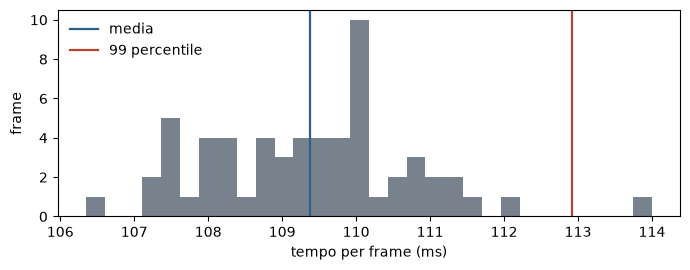

In [20]:
import numpy as np, cv2, time, matplotlib.pyplot as plt
import pathlib, urllib.request, zipfile, io
D = pathlib.Path("dati-video")
if not (D / "clip.mp4").exists():
    U = "https://github.com/nunziati/zcs-ai-course-2026/releases/download/dati-video/8calves-clip.zip"
    with urllib.request.urlopen(U) as r: zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)
# PUNTO DI VARIAZIONE
# yolo11n, yolo11s, yolo11m (AGPL-3.0)   oppure   rtdetr (Apache 2.0)
DETECTOR = "yolo11m"
ANIMALI = {"cow", "dog", "bird", "sheep", "bear", "cat", "horse", "elephant", "zebra", "giraffe"}
def serve(modulo, pacchetto=None):
    """Su Colab ultralytics non c'e'. Si installa una volta sola, al primo uso."""
    import importlib, subprocess, sys
    try: return importlib.import_module(modulo)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pacchetto or modulo], check=True)
        return importlib.import_module(modulo)

if DETECTOR.startswith("yolo"):
    serve("ultralytics")
    from ultralytics import YOLO
    mod = YOLO(DETECTOR + ".pt")
    def rileva(im, lato=640, soglia=0.10):
        r = mod.predict(im, verbose=False, imgsz=lato, conf=soglia)[0]
        return (r.boxes.xyxy.numpy(), r.boxes.conf.numpy(),
                [r.names[int(k)] for k in r.boxes.cls])
else:
    import torch
    from PIL import Image
    serve("transformers", "transformers>=4.47")
    from transformers import RTDetrV2ForObjectDetection, RTDetrImageProcessor
    CK = "PekingU/rtdetr_v2_r18vd"
    proc = RTDetrImageProcessor.from_pretrained(CK)
    mod = RTDetrV2ForObjectDetection.from_pretrained(CK).eval()
    def rileva(im, lato=640, soglia=0.10):
        img = Image.fromarray(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        misura = {"height": lato, "width": lato}
        with torch.no_grad():
            out = mod(**proc(images=img, return_tensors="pt", size=misura))
        r = proc.post_process_object_detection(
            out, target_sizes=torch.tensor([[600, 800]]), threshold=soglia)[0]
        return (r["boxes"].numpy(), r["scores"].numpy(),
                [mod.config.id2label[k.item()] for k in r["labels"]])
INK, MUTED, BLU, ROS = "#1f2933", "#77828c", "#2c5f8a", "#b8422f"

N = 60
c = cv2.VideoCapture(str(D / "clip.mp4"))
ok, im0 = c.read(); rileva(im0, 640, 0.25)
c.release()

c = cv2.VideoCapture(str(D / "clip.mp4"))
t = []
for _ in range(N):
    t0 = time.perf_counter()
    ok, im = c.read()
    if not ok: break
    rileva(im, 640, 0.25)
    t.append((time.perf_counter() - t0) * 1000)
c.release()
t = np.array(t)

print(f"detector: {DETECTOR}, {len(t)} frame, tempo per frame in millisecondi")
print(f"  media      {t.mean():7.1f}")
print(f"  mediana    {np.median(t):7.1f}")
print(f"  95 pct     {np.percentile(t, 95):7.1f}")
print(f"  99 pct     {np.percentile(t, 99):7.1f}")
print(f"  massimo    {t.max():7.1f}")
print(f"\nrapporto fra 99 percentile e media: {np.percentile(t, 99) / t.mean():.2f}")
LIMITE = 1000 / 20
oltre = float((t > LIMITE).mean())
print(f"frame oltre il limite di {LIMITE:.0f} ms imposto da venti frame al secondo: {oltre:.1%}")
print("\nUn sistema dimensionato sulla media perde i frame della coda, e il valore da")
print("dichiarare e' un percentile alto misurato sulla pipeline completa.")
print("Qui la distribuzione e' stretta, perche' la macchina e' scarica e il costo del")
print("modello non dipende da quanti oggetti ci sono. La coda si allunga quando l'hardware")
print("e' condiviso con altro, quando il post-processing costa in proporzione alle")
print("detection, e quando la sorgente e' una rete invece di un file.")

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.hist(t, bins=30, color=MUTED)
ax.axvline(t.mean(), color=BLU, lw=1.6, label="media")
ax.axvline(np.percentile(t, 99), color=ROS, lw=1.6, label="99 percentile")
ax.set_xlabel("tempo per frame (ms)"); ax.set_ylabel("frame")
ax.legend(frameon=False); fig.tight_layout(); plt.show()